In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

import keypoint_moseq as kpms

In [4]:
dlc_videos_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions")

pcutoff = 0.8
dlc_folders_dataset = [str(f) for f in dlc_videos_path.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5")]

dataset = []

for f in dlc_folders_dataset:
    folder = Path(f).parent.parent 
    if (folder/"flag1.txt").exists() or not (folder/"flag.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5"))))
    elif (folder/"flag.txt").exists() and not (folder/"flag1.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_transformer\*snapshot_best-100_sk_tr.h5"))))

In [6]:
# Groups

Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

In [7]:
kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS"
model = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0"

addResultsPath = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\additionalVideos\mouse978528_Day16_results.h5"

#results = kpms.load_results(kpmoseq_dir, model)
#addResults = kpms.load_results(path = addResultsPath)
'''
for key, value in addResults.items():
    results[key] = value
'''
results = {}
batchResultsPath = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\batchResults_test")
batchResults = [f for f in batchResultsPath.rglob("*.h5")]

for it in batchResults:
    r = kpms.load_results(path = it)
    for key, values in r.items():
        results[key] = values

filtered_results = {
    k: v for k, v in results.items()
    if "_topView_compDLC_" not in k # These were keys that come from a previous iteration of the model training. They have duplicates in the correct format 
}

if filtered_results["mouse1034805_Day19"]:
    del filtered_results["mouse1034805_Day19"]

In [8]:
kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS"
model = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0"

addResultsPath = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\additionalVideos\mouse978528_Day16_results.h5"

results = kpms.load_results(kpmoseq_dir, model)
addResults = kpms.load_results(path = addResultsPath)
'''
for key, value in addResults.items():
    results[key] = value
'''
    
filtered_results = {
    k: v for k, v in results.items()
    if "_topView_compDLC_" not in k # These were keys that come from a previous iteration of the model training. They have duplicates in the correct format 
}

if filtered_results["mouse1034805_Day19"]:
    del filtered_results["mouse1034805_Day19"]

In [9]:
rows = []
skipped = []

saline_mice = maladaptive[:3]
psilo_mice = maladaptive[3:]   # non-overlapping

for video in filtered_results.keys():

    m = re.match(r"mouse(\d+)_Day(\d+)", video)

    if m is None:
        skipped.append({"recording": video, "reason": "regex_no_match"})
        continue

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
            group = "Agg"

    elif mouse in nonAgg:
            group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive Psilocybin"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive Saline"

    else:
        skipped.append({
            "recording": video,
            "mouse": mouse,
            "day": day,
            "reason": "mouse_not_in_group_lists"
        })
        continue

    mouse_group_id = f"{mouse}_{group}"

    rows.append({
        "video": video,
        "mouse": mouse,                 # original animal ID
        "mouse_group_id": mouse_group_id, # analysis ID
        "day": day,
        "group": group
    })

resultsDataset = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

In [10]:
all_syllables=[]

for rec in filtered_results:
    all_syllables.extend(
        filtered_results[rec]["syllable"]
    )

n_syll = len(np.unique(all_syllables))

In [11]:
usage = []

for rec in filtered_results:

    s = np.asarray(filtered_results[rec]["syllable"])

    row = {"video": rec}

    if len(s) == 0:
        freq = np.zeros(n_syll)
    else:
        counts = np.bincount(s, minlength=n_syll)
        total = counts.sum()

        if total == 0:
            freq = np.zeros(n_syll)
        else:
            freq = counts / total

    for i, f in enumerate(freq):
        row[f"syll_{i}"] = f

    usage.append(row)

usage = pd.DataFrame(usage).fillna(0)
df = resultsDataset.merge(usage, on="video", how="inner")

In [12]:
mouse_df = (
    df.groupby(["mouse_group_id", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import KFold


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive"
]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)


# -----------------------------
# prepare data
# IMPORTANT:
# use video-level df, not mouse_df
# -----------------------------
plot_df = df.copy()

plot_df["group"] = plot_df["group"].astype(str).str.strip()
plot_df["day"] = pd.to_numeric(plot_df["day"], errors="coerce")


# -----------------------------
# remove psilocybin post-treatment videos
# -----------------------------
plot_df = plot_df[
    ~plot_df["group"].isin([
        "maladaptive Psilocybin",
        "maladaptive after Psilocybin"
    ])
].copy()


# -----------------------------
# merge groups for plotting / analysis
# -----------------------------
plot_df["group_plot"] = plot_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})


# -----------------------------
# keep groups of interest
# -----------------------------
plot_df = plot_df[
    plot_df["group_plot"].isin(group_order)
].copy()


print("Video-level groups before mouse averaging:")
print(plot_df["group"].value_counts())

print("\nMerged video-level groups before mouse averaging:")
print(plot_df["group_plot"].value_counts())

print("\nVideos per mouse/group before averaging:")
print(
    plot_df
    .groupby(["mouse", "group", "group_plot"])
    .size()
    .reset_index(name="n_videos")
    .sort_values(["group_plot", "mouse", "group"])
)


# -----------------------------
# collapse all videos/days to one row per mouse
# baseline + saline from same mouse become one maladaptive point
# -----------------------------
plot_df = (
    plot_df
    .groupby(["mouse", "group_plot"], as_index=False)
    .mean(numeric_only=True)
)


group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

print("\nGroups included after mouse averaging:")
print(plot_df["group_plot"].value_counts())

print("\nMouse/group rows after averaging:")
print(
    plot_df[["mouse", "group_plot"]]
    .sort_values(["group_plot", "mouse"])
)


# -----------------------------
# features
# -----------------------------
X_df = plot_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

min_recordings = 1
presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= min_recordings].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)


# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_plot"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = int(len(valid_features) / 3)
top_features = mi_scores.head(top_n).index

print("\nTop MI features:")
print(mi_scores.head(top_n))


# -----------------------------
# cvPCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

n_components = 2
n_splits = min(5, X_selected_scaled.shape[0])

kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

cv_explained = np.zeros(n_components)
cv_total_var = 0.0

for train_idx, test_idx in kf.split(X_selected_scaled):

    X_train = X_selected_scaled[train_idx]
    X_test = X_selected_scaled[test_idx]

    # fit PCA only on training mice
    pca_fold = PCA(n_components=n_components)
    pca_fold.fit(X_train)

    # project held-out mice onto train PCs
    X_test_scores = pca_fold.transform(X_test)

    # total held-out variance
    cv_total_var += np.sum(X_test ** 2)

    # cross-validated variance explained by each PC
    for pc in range(n_components):
        scores_pc = X_test_scores[:, [pc]]
        components_pc = pca_fold.components_[[pc], :]
        recon_pc = scores_pc @ components_pc

        cv_explained[pc] += np.sum(recon_pc ** 2)

cv_explained_variance_ratio = cv_explained / cv_total_var


# -----------------------------
# final PCA fit for coordinates/loadings
# -----------------------------
# cvPCA estimates held-out explained variance.
# The plotted PC coordinates/loadings are from PCA fit on all mice.
pca = PCA(n_components=n_components)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

# store cvPCA variance on the PCA object for plotting labels
pca.cv_explained_variance_ratio_ = cv_explained_variance_ratio

print("\nCross-validated explained variance:")
print(f"cvPC1: {pca.cv_explained_variance_ratio_[0] * 100:.1f}%")
print(f"cvPC2: {pca.cv_explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total cvPC1 + cvPC2: {pca.cv_explained_variance_ratio_[:2].sum() * 100:.1f}%")

print("\nRegular PCA explained variance, for comparison:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")


# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)


# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]


# -----------------------------
# per-group syllable contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_plot"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order_present]


# -----------------------------
# same color range for loading barplot and heatmap
# -----------------------------
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])


# -----------------------------
# output
# -----------------------------
mouse_pca_df = plot_df.copy()

Video-level groups before mouse averaging:
group
Agg                     101
nonAgg                   87
maladaptive baseline     35
maladaptive Saline       11
Name: count, dtype: int64

Merged video-level groups before mouse averaging:
group_plot
Agg            101
nonAgg          87
maladaptive     46
Name: count, dtype: int64

Videos per mouse/group before averaging:
      mouse                 group   group_plot  n_videos
1   1010820                   Agg          Agg        11
2   1010823                   Agg          Agg        11
3   1010826                   Agg          Agg        11
8   1029741                   Agg          Agg        10
12   975826                   Agg          Agg         9
13   975827                   Agg          Agg         7
15   975833                   Agg          Agg         9
22   978772                   Agg          Agg         8
23   978774                   Agg          Agg         8
25   988590                   Agg          Agg         9

In [17]:
# -----------------------------
# plotting
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}, dpi = 800
)

# -----------------------------
# choose the correct group column
# -----------------------------
if "group_plot" in plot_df.columns:
    group_col = "group_plot"
elif "group_merged" in plot_df.columns:
    group_col = "group_merged"
else:
    raise KeyError("Neither 'group_plot' nor 'group_merged' exists in plot_df.")

group_order_present = [
    g for g in group_order
    if g in plot_df[group_col].unique()
]

violin_data = [
    plot_df.loc[plot_df[group_col] == g, "PC1"].values
    for g in group_order_present
]

heat_plot = heat[group_order_present]

# -----------------------------
# 1. PCA cloud
# -----------------------------
# detect the mouse-id column once
mouse_col = next(
    (c for c in ["mouse", "mouse_group_id", "video", "video_path"] if c in plot_df.columns),
    None
)

ax = axes[0, 0]

for g in group_order_present:
    sub = plot_df[plot_df[group_col] == g]

    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

    if mouse_col is not None:
        for _, row in sub.iterrows():
            ax.annotate(
                str(row[mouse_col]),
                (row["PC1"], row["PC2"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=6,
                alpha=0.75
            )

ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")


# -----------------------------
# 2. Top PC1 syllable weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Syllable")
ax.set_title("Top syllable weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")


# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order_present):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order_present) + 1))
ax.set_xticklabels(group_order_present, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")


# -----------------------------
# 4. Syllable contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    heat_plot,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat_plot.columns)))
ax.set_xticklabels(heat_plot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heat_plot.index)))
ax.set_yticklabels(heat_plot.index)

ax.set_title("Syllable contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

27 mice (one row each), 99 syllables, 5-fold CV, classes=['nonAgg', 'Agg', 'maladaptive']
per class: {'nonAgg': 9, 'Agg': 11, 'maladaptive': 7}

===== 3-class macro OVR ROC-AUC (leak-free, animal-level) =====
  MI top 33 (selected in-fold): AUC=0.951  perm p=0.0050 (null 0.493)
  all 99 syllables          : AUC=0.924  perm p=0.0050 (null 0.488)

  all-syllable balanced accuracy = 0.818
  confusion (rows=true, cols=pred): ['nonAgg', 'Agg', 'maladaptive']
[[7 2 0]
 [2 9 0]
 [0 1 6]]

===== pairwise leak-free CV ROC-AUC =====
  nonAgg      vs Agg         : AUC=0.919  perm p=0.0100 (null 0.479)
  Agg         vs maladaptive : AUC=0.974  perm p=0.0050 (null 0.473)
  nonAgg      vs maladaptive : AUC=1.000  perm p=0.0100 (null 0.497)


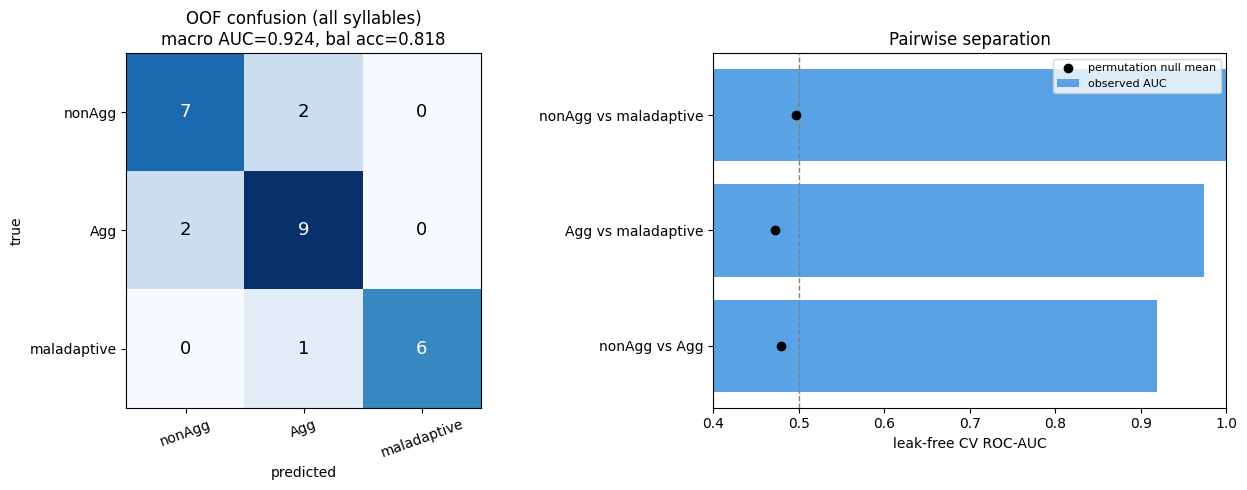


All rows are per-mouse averages, so folds never split a mouse (animal-level by construction). MI selection runs inside each fold.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

SEED = 42
rng = np.random.default_rng(SEED)

group_col = "group_plot" if "group_plot" in plot_df.columns else "group_merged"
classes = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in plot_df[group_col].unique()]
codes = {g: i for i, g in enumerate(classes)}

# --- features: ALL syllables, log-transformed (one row per mouse already) ---
Xdf = plot_df.filter(regex="^syll_").replace([np.inf, -np.inf], np.nan).fillna(0)
Xlog = np.log(Xdf.values + 1e-8)
ylab = plot_df[group_col].values
y = np.array([codes[g] for g in ylab])
n_feat = Xlog.shape[1]
k_mi = max(1, n_feat // 3)
n_split = min(5, min(np.bincount(y)))     # never more folds than smallest class
print(f"{Xlog.shape[0]} mice (one row each), {n_feat} syllables, "
      f"{n_split}-fold CV, classes={classes}")
print("per class:", dict(zip(classes, np.bincount(y))))

mi = partial(mutual_info_classif, random_state=SEED)
cv = StratifiedKFold(n_split, shuffle=True, random_state=SEED)

def make_pipe(k=None, C=0.5):
    steps = [("scale", StandardScaler())]
    if k is not None:
        steps.append(("sel", SelectKBest(mi, k=k)))      # MI selection INSIDE fold
    steps.append(("clf", LogisticRegression(max_iter=5000, C=C,
                                            class_weight="balanced")))
    return Pipeline(steps)

def oof_macro_auc(pipe, X, yy):
    pr = cross_val_predict(pipe, X, yy, cv=cv, method="predict_proba")
    return roc_auc_score(yy, pr, multi_class="ovr", average="macro"), pr

def perm_p(pipe, X, yy, obs, n=200):
    null = np.array([oof_macro_auc(pipe, X, rng.permutation(yy))[0] for _ in range(n)])
    return (1 + np.sum(null >= obs)) / (n + 1), null.mean()

# =====================================================================
# 3-CLASS leak-free CV : MI-selected (matches figure) vs all-syllables
# =====================================================================
auc_mi, proba_mi = oof_macro_auc(make_pipe(k=k_mi), Xlog, y)
auc_all, proba_all = oof_macro_auc(make_pipe(k=None), Xlog, y)
p_mi,  null_mi  = perm_p(make_pipe(k=k_mi), Xlog, y, auc_mi)
p_all, null_all = perm_p(make_pipe(k=None), Xlog, y, auc_all)

print("\n===== 3-class macro OVR ROC-AUC (leak-free, animal-level) =====")
print(f"  MI top {k_mi} (selected in-fold): AUC={auc_mi:.3f}  "
      f"perm p={p_mi:.4f} (null {null_mi:.3f})")
print(f"  all {n_feat} syllables          : AUC={auc_all:.3f}  "
      f"perm p={p_all:.4f} (null {null_all:.3f})")

# confusion matrix + balanced acc from the all-syllable model (no selection step)
pred = proba_all.argmax(1)
bacc = balanced_accuracy_score(y, pred)
cm = confusion_matrix(y, pred)
print(f"\n  all-syllable balanced accuracy = {bacc:.3f}")
print("  confusion (rows=true, cols=pred):", classes)
print(cm)

# =====================================================================
# PAIRWISE leak-free CV (the contrasts that matter), all-syllable model
# =====================================================================
def binary_cv(ga, gb, n_perm=200):
    m = np.isin(ylab, [ga, gb])
    Xs, ys = Xlog[m], (ylab[m] == gb).astype(int)
    ns = min(5, min(np.bincount(ys)))
    cvb = StratifiedKFold(ns, shuffle=True, random_state=SEED)
    pipe = make_pipe(k=None)
    pr = cross_val_predict(pipe, Xs, ys, cv=cvb, method="predict_proba")[:, 1]
    auc = roc_auc_score(ys, pr)
    null = []
    for _ in range(n_perm):
        yp = rng.permutation(ys)
        prp = cross_val_predict(pipe, Xs, yp, cv=cvb, method="predict_proba")[:, 1]
        null.append(roc_auc_score(yp, prp))
    null = np.array(null)
    return auc, (1 + np.sum(null >= auc)) / (n_perm + 1), null.mean()

print("\n===== pairwise leak-free CV ROC-AUC =====")
pairs = [("nonAgg", "Agg"), ("Agg", "maladaptive"), ("nonAgg", "maladaptive")]
pair_res = {}
for ga, gb in pairs:
    if ga in classes and gb in classes:
        a, p, nm = binary_cv(ga, gb)
        pair_res[f"{ga} vs {gb}"] = (a, p, nm)
        print(f"  {ga:11s} vs {gb:12s}: AUC={a:.3f}  perm p={p:.4f} (null {nm:.3f})")

# =====================================================================
# FIGURE
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks(range(len(classes))); ax[0].set_xticklabels(classes, rotation=20)
ax[0].set_yticks(range(len(classes))); ax[0].set_yticklabels(classes)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
ax[0].set_title(f"OOF confusion (all syllables)\nmacro AUC={auc_all:.3f}, bal acc={bacc:.3f}")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax[0].text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)

names = list(pair_res.keys())
aucs = [pair_res[n][0] for n in names]
nulls = [pair_res[n][2] for n in names]
ax[1].barh(names, aucs, color="#5AA2E6", label="observed AUC")
ax[1].scatter(nulls, names, color="black", zorder=5, label="permutation null mean")
ax[1].axvline(0.5, color="grey", ls="--", lw=1)
ax[1].set_xlim(0.4, 1.0); ax[1].set_xlabel("leak-free CV ROC-AUC")
ax[1].set_title("Pairwise separation"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nAll rows are per-mouse averages, so folds never split a mouse "
      "(animal-level by construction). MI selection runs inside each fold.")

27 mice, 99 syllables, 5-fold CV, classes=['nonAgg', 'Agg', 'maladaptive']
per class: {'nonAgg': 9, 'Agg': 11, 'maladaptive': 7}

===== 3-class macro OVR ROC-AUC (leak-free, animal-level) =====
  Logistic (L2)    | MI top 33   : AUC=0.951  perm p=0.0050 (null 0.493)
  Logistic (L2)    | all 99      : AUC=0.924  perm p=0.0050 (null 0.488)
  Shrinkage LDA    | MI top 33   : AUC=1.000  perm p=0.0050 (null 0.482)
  Shrinkage LDA    | all 99      : AUC=0.996  perm p=0.0050 (null 0.487)

===== pairwise leak-free CV ROC-AUC (both models) =====
  Logistic (L2)    | nonAgg  vs Agg         : AUC=0.919  p=0.0050 (null 0.523)
  Logistic (L2)    | Agg     vs maladaptive : AUC=0.974  p=0.0050 (null 0.490)
  Logistic (L2)    | nonAgg  vs maladaptive : AUC=1.000  p=0.0050 (null 0.472)
  Shrinkage LDA    | nonAgg  vs Agg         : AUC=0.980  p=0.0100 (null 0.516)
  Shrinkage LDA    | Agg     vs maladaptive : AUC=0.974  p=0.0050 (null 0.475)
  Shrinkage LDA    | nonAgg  vs maladaptive : AUC=1.000  p=0.0

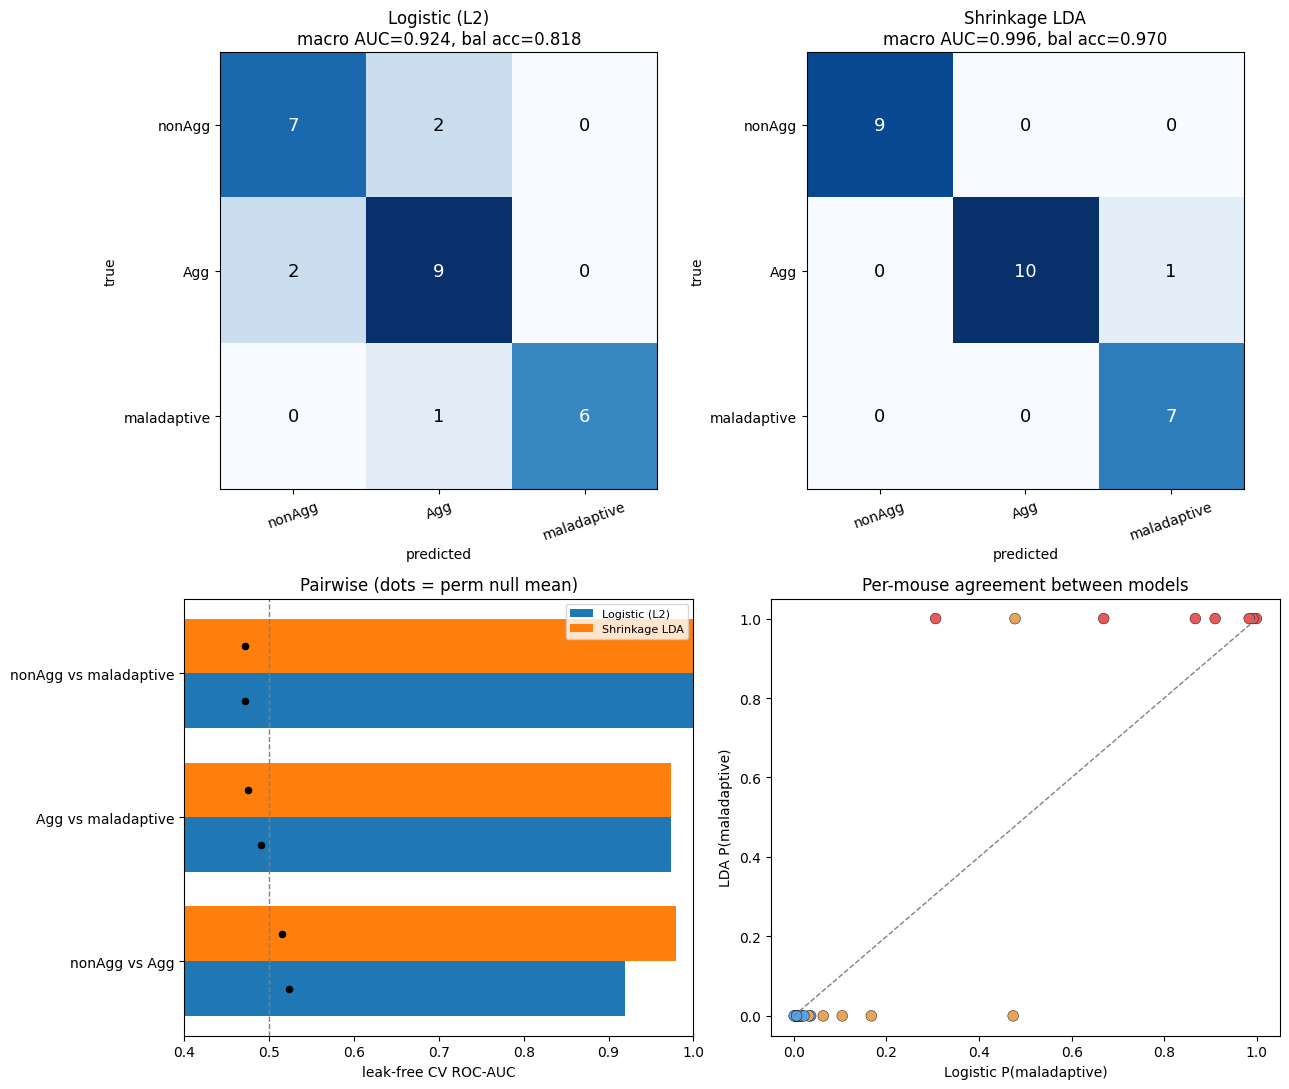


Two independent linear models. If both clear their nulls and agree per-mouse (points on the diagonal), the separation is not an artifact of one classifier's assumptions.


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

SEED = 42
rng = np.random.default_rng(SEED)

group_col = "group_plot" if "group_plot" in plot_df.columns else "group_merged"
classes = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in plot_df[group_col].unique()]
codes = {g: i for i, g in enumerate(classes)}

Xdf = plot_df.filter(regex="^syll_").replace([np.inf, -np.inf], np.nan).fillna(0)
Xlog = np.log(Xdf.values + 1e-8)
ylab = plot_df[group_col].values
y = np.array([codes[g] for g in ylab])
n_feat = Xlog.shape[1]
k_mi = max(1, n_feat // 3)
n_split = min(5, min(np.bincount(y)))
print(f"{Xlog.shape[0]} mice, {n_feat} syllables, {n_split}-fold CV, classes={classes}")
print("per class:", dict(zip(classes, np.bincount(y))))

mi = partial(mutual_info_classif, random_state=SEED)
cv = StratifiedKFold(n_split, shuffle=True, random_state=SEED)

# --- two linear classifiers ---
def clf_step(name):
    if name == "logreg":
        return ("clf", LogisticRegression(max_iter=5000, C=0.5, class_weight="balanced"))
    if name == "lda":   # shrinkage LDA: stable when features > samples
        return ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))

def make_pipe(name, k=None):
    steps = [("scale", StandardScaler())]
    if k is not None:
        steps.append(("sel", SelectKBest(mi, k=k)))   # selection inside fold
    steps.append(clf_step(name))
    return Pipeline(steps)

def oof_macro_auc(pipe, X, yy):
    pr = cross_val_predict(pipe, X, yy, cv=cv, method="predict_proba")
    return roc_auc_score(yy, pr, multi_class="ovr", average="macro"), pr

def perm_p(pipe, X, yy, obs, n=200):
    null = np.array([oof_macro_auc(pipe, X, rng.permutation(yy))[0] for _ in range(n)])
    return (1 + np.sum(null >= obs)) / (n + 1), null.mean()

MODELS = {"logreg": "Logistic (L2)", "lda": "Shrinkage LDA"}

# =====================================================================
# 3-class macro AUC, each model x {MI-selected, all syllables}
# =====================================================================
print("\n===== 3-class macro OVR ROC-AUC (leak-free, animal-level) =====")
results = {}   # (model, mode) -> dict
for name, lbl in MODELS.items():
    for mode, k in [("MI top %d" % k_mi, k_mi), ("all %d" % n_feat, None)]:
        pipe = make_pipe(name, k=k)
        auc, proba = oof_macro_auc(pipe, Xlog, y)
        pp, nm = perm_p(pipe, Xlog, y, auc)
        results[(name, mode)] = dict(auc=auc, p=pp, null=nm, proba=proba)
        print(f"  {lbl:16s} | {mode:12s}: AUC={auc:.3f}  perm p={pp:.4f} (null {nm:.3f})")

# confusion matrix from each model's all-syllable version
def cm_bacc(name):
    proba = results[(name, "all %d" % n_feat)]["proba"]
    pred = proba.argmax(1)
    return confusion_matrix(y, pred), balanced_accuracy_score(y, pred)

# =====================================================================
# pairwise, both models (all-syllable)
# =====================================================================
def binary_cv(name, ga, gb, n_perm=200):
    m = np.isin(ylab, [ga, gb])
    Xs, ys = Xlog[m], (ylab[m] == gb).astype(int)
    ns = min(5, min(np.bincount(ys)))
    cvb = StratifiedKFold(ns, shuffle=True, random_state=SEED)
    pipe = make_pipe(name, k=None)
    pr = cross_val_predict(pipe, Xs, ys, cv=cvb, method="predict_proba")[:, 1]
    auc = roc_auc_score(ys, pr)
    null = np.array([roc_auc_score(yp := rng.permutation(ys),
                     cross_val_predict(pipe, Xs, yp, cv=cvb, method="predict_proba")[:, 1])
                     for _ in range(n_perm)])
    return auc, (1 + np.sum(null >= auc)) / (n_perm + 1), null.mean()

pairs = [("nonAgg", "Agg"), ("Agg", "maladaptive"), ("nonAgg", "maladaptive")]
print("\n===== pairwise leak-free CV ROC-AUC (both models) =====")
pair_res = {name: {} for name in MODELS}
for name, lbl in MODELS.items():
    for ga, gb in pairs:
        if ga in classes and gb in classes:
            a, p, nm = binary_cv(name, ga, gb)
            pair_res[name][f"{ga} vs {gb}"] = (a, p, nm)
            print(f"  {lbl:16s} | {ga:7s} vs {gb:12s}: AUC={a:.3f}  p={p:.4f} (null {nm:.3f})")

# =====================================================================
# FIGURE: confusion per model (top) + pairwise comparison (bottom)
# =====================================================================
fig, ax = plt.subplots(2, 2, figsize=(13, 11))
for col, (name, lbl) in enumerate(MODELS.items()):
    cm, bacc = cm_bacc(name)
    a = ax[0, col]
    a.imshow(cm, cmap="Blues")
    a.set_xticks(range(len(classes))); a.set_xticklabels(classes, rotation=20)
    a.set_yticks(range(len(classes))); a.set_yticklabels(classes)
    a.set_xlabel("predicted"); a.set_ylabel("true")
    auc_all = results[(name, "all %d" % n_feat)]["auc"]
    a.set_title(f"{lbl}\nmacro AUC={auc_all:.3f}, bal acc={bacc:.3f}")
    for i in range(len(classes)):
        for j in range(len(classes)):
            a.text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)

# pairwise side-by-side bars
a = ax[1, 0]
labels = list(next(iter(pair_res.values())).keys())
yloc = np.arange(len(labels)); h = 0.38
for off, (name, lbl) in zip([-h/2, h/2], MODELS.items()):
    vals = [pair_res[name][l][0] for l in labels]
    a.barh(yloc + off, vals, height=h, label=lbl)
    a.scatter([pair_res[name][l][2] for l in labels], yloc + off,
              color="black", s=20, zorder=5)
a.set_yticks(yloc); a.set_yticklabels(labels)
a.axvline(0.5, color="grey", ls="--", lw=1); a.set_xlim(0.4, 1.0)
a.set_xlabel("leak-free CV ROC-AUC"); a.set_title("Pairwise (dots = perm null mean)")
a.legend(fontsize=8)

# agreement scatter: per-mouse maladaptive-probability, logreg vs lda
a = ax[1, 1]
pm_lr = results[("logreg", "all %d" % n_feat)]["proba"][:, classes.index("maladaptive")] \
        if "maladaptive" in classes else None
pm_ld = results[("lda", "all %d" % n_feat)]["proba"][:, classes.index("maladaptive")] \
        if "maladaptive" in classes else None
if pm_lr is not None:
    cols = np.array([{"nonAgg": "#5AA2E6", "Agg": "#E6A55A",
                      "maladaptive": "#E65A5A"}[g] for g in ylab])
    a.scatter(pm_lr, pm_ld, c=cols, s=60, edgecolor="black", linewidth=0.3)
    a.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    a.set_xlabel("Logistic P(maladaptive)"); a.set_ylabel("LDA P(maladaptive)")
    a.set_title("Per-mouse agreement between models")
plt.tight_layout(); plt.show()

print("\nTwo independent linear models. If both clear their nulls and agree "
      "per-mouse (points on the diagonal), the separation is not an artifact "
      "of one classifier's assumptions.")

In [103]:
# ---- which mice are misclassified (out-of-fold), per model ----
mouse_ids = (plot_df["mouse"].values if "mouse" in plot_df.columns
             else np.arange(len(ylab)))

for name, lbl in MODELS.items():
    proba = results[(name, "all %d" % n_feat)]["proba"]
    pred_idx = proba.argmax(1)
    pred_lab = np.array([classes[i] for i in pred_idx])
    pmal = proba[:, classes.index("maladaptive")] if "maladaptive" in classes else np.full(len(ylab), np.nan)

    wrong = pred_lab != ylab
    print(f"\n===== {lbl}: {wrong.sum()} misclassified (out-of-fold) =====")
    if wrong.sum():
        tab = pd.DataFrame({
            "mouse": mouse_ids[wrong],
            "true": ylab[wrong],
            "predicted": pred_lab[wrong],
            "P(true)": proba[wrong, [codes[g] for g in ylab[wrong]]].round(3),
            "P(pred)": proba[wrong].max(1).round(3),
            "P(maladaptive)": pmal[wrong].round(3),
        }).sort_values(["true", "predicted"])
        print(tab.to_string(index=False))


===== Logistic (L2): 5 misclassified (out-of-fold) =====
  mouse        true predicted  P(true)  P(pred)  P(maladaptive)
 975827         Agg    nonAgg    0.159    0.674           0.167
 978772         Agg    nonAgg    0.187    0.708           0.104
 978527 maladaptive       Agg    0.306    0.686           0.306
1010819      nonAgg       Agg    0.285    0.712           0.003
 978775      nonAgg       Agg    0.262    0.730           0.007

===== Shrinkage LDA: 1 misclassified (out-of-fold) =====
  mouse true   predicted  P(true)  P(pred)  P(maladaptive)
1029741  Agg maladaptive      0.0      1.0             1.0


Psilocybin mice projected through maladaptive-trained LDA:

  mouse  pred_label  P_nonAgg  P_Agg  P_maladaptive  P_mal_baseline_insample
1010832 maladaptive       0.0    0.0            1.0                      1.0
1013590 maladaptive       0.0    0.0            1.0                      1.0
1034805 maladaptive       0.0    0.0            1.0                      1.0
1034814 maladaptive       0.0    0.0            1.0                      1.0

Predicted-label counts:
maladaptive    4

4/4 psilocybin mice matched to their own baseline point.


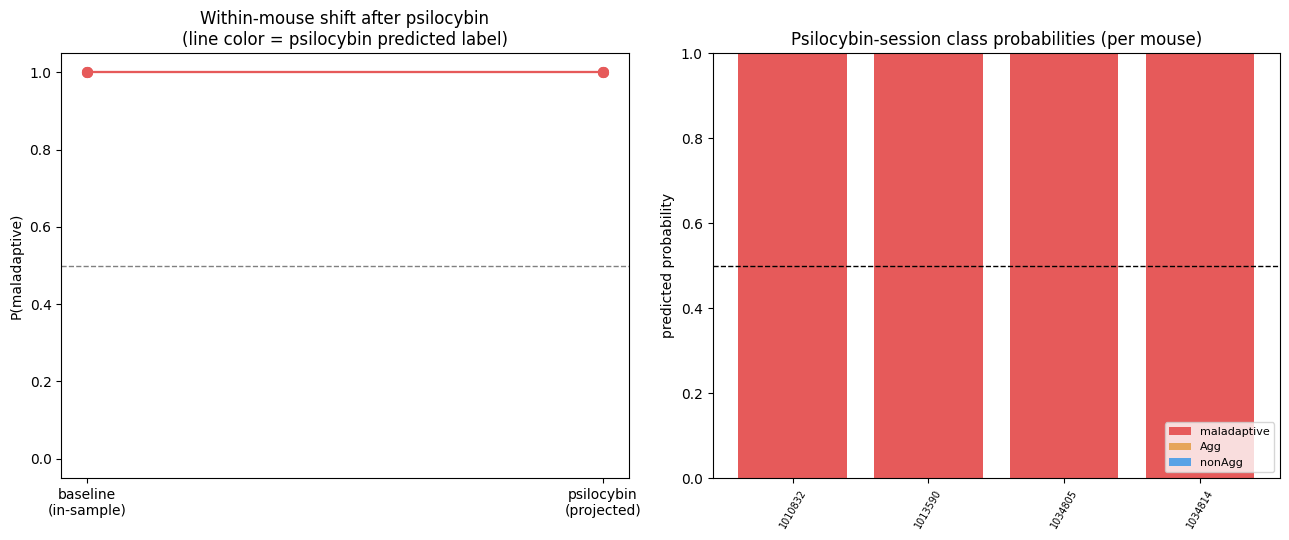


Of 4 psilocybin mice: 4 stay 'maladaptive', 0 shift to 'Agg', 0 to 'nonAgg'.
Reminder: within-subject readout (these animals' baseline trained the model), not independent validation. Baseline P is in-sample (optimistic ~1). Saline was merged into the maladaptive training point, so this is psilocybin-vs-own-baseline, not psilocybin-vs-saline-control.


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================================
# Fit shrinkage LDA on the merged 3-class per-mouse table (the training set),
# then PROJECT the held-out maladaptive-Psilocybin mice through it.
# =====================================================================
group_col = "group_plot" if "group_plot" in plot_df.columns else "group_merged"
classes = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in plot_df[group_col].unique()]

# --- training features (all syllables, log) ---
train_syll = plot_df.filter(regex="^syll_").replace([np.inf, -np.inf], np.nan).fillna(0)
feat_cols = train_syll.columns
Xtr = np.log(train_syll.values + 1e-8)
ytr = plot_df[group_col].values

pipe = Pipeline([("scale", StandardScaler()),
                 ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))])
pipe.fit(Xtr, ytr)
cls = list(pipe.classes_)            # proba column order
iMal = cls.index("maladaptive")
iAgg = cls.index("Agg")

# --- pull psilocybin mice from the ORIGINAL df (excluded from training) ---
assert "df" in dir(), "Need the original video-level df (before psilocybin removal)."
gcol_raw = "group"
psilo_labels = ["maladaptive Psilocybin", "maladaptive after Psilocybin"]
psilo = df[df[gcol_raw].astype(str).str.strip().isin(psilo_labels)].copy()
if len(psilo) == 0:
    raise ValueError("No psilocybin rows found in df under those group labels.")

psilo_mouse = psilo.groupby("mouse", as_index=False).mean(numeric_only=True)
psilo_feat = (psilo_mouse.filter(regex="^syll_")
              .reindex(columns=feat_cols, fill_value=0)
              .replace([np.inf, -np.inf], np.nan).fillna(0))
Xps = np.log(psilo_feat.values + 1e-8)

proba_ps = pipe.predict_proba(Xps)
pred_ps = pipe.predict(Xps)

# --- baseline (in-sample) probability for the SAME mice, for a paired shift ---
proba_tr = pipe.predict_proba(Xtr)
tr = pd.DataFrame({"mouse": plot_df["mouse"].values, "grp": ytr,
                   "P_mal_base": proba_tr[:, iMal]})
base_map = (tr[tr["grp"] == "maladaptive"]
            .set_index("mouse")["P_mal_base"].to_dict())

# --- assemble result table ---
res = pd.DataFrame({
    "mouse": psilo_mouse["mouse"].values,
    "pred_label": pred_ps,
    "P_nonAgg": proba_ps[:, cls.index("nonAgg")],
    "P_Agg": proba_ps[:, iAgg],
    "P_maladaptive": proba_ps[:, iMal],
})
res["P_mal_baseline_insample"] = res["mouse"].map(base_map)
res = res.sort_values("P_maladaptive").reset_index(drop=True)

print("Psilocybin mice projected through maladaptive-trained LDA:\n")
print(res.round(3).to_string(index=False))
print("\nPredicted-label counts:")
print(pd.Series(pred_ps).value_counts().to_string())
matched = res["P_mal_baseline_insample"].notna().sum()
print(f"\n{matched}/{len(res)} psilocybin mice matched to their own baseline point.")

# =====================================================================
# FIGURE
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
lab_color = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}

# (a) paired within-mouse shift in P(maladaptive): baseline (in-sample) -> psilocybin
m = res["P_mal_baseline_insample"].notna()
for _, r in res[m].iterrows():
    ax[0].plot([0, 1], [r["P_mal_baseline_insample"], r["P_maladaptive"]],
               "-o", color=lab_color[r["pred_label"]], alpha=0.8, markersize=7)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["baseline\n(in-sample)", "psilocybin\n(projected)"])
ax[0].set_ylabel("P(maladaptive)"); ax[0].set_ylim(-0.05, 1.05)
ax[0].axhline(0.5, color="grey", ls="--", lw=1)
ax[0].set_title("Within-mouse shift after psilocybin\n(line color = psilocybin predicted label)")

# (b) per-mouse psilocybin class probabilities, stacked
order = res.sort_values("P_maladaptive").reset_index(drop=True)
xpos = np.arange(len(order))
ax[1].bar(xpos, order["P_maladaptive"], color="#E65A5A", label="maladaptive")
ax[1].bar(xpos, order["P_Agg"], bottom=order["P_maladaptive"], color="#E6A55A", label="Agg")
ax[1].bar(xpos, order["P_nonAgg"],
          bottom=order["P_maladaptive"] + order["P_Agg"], color="#5AA2E6", label="nonAgg")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(order["mouse"].astype(str), rotation=60, fontsize=7)
ax[1].set_ylabel("predicted probability"); ax[1].set_ylim(0, 1)
ax[1].axhline(0.5, color="black", ls="--", lw=1)
ax[1].set_title("Psilocybin-session class probabilities (per mouse)")
ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

n_agg = int((pred_ps == "Agg").sum())
n_mal = int((pred_ps == "maladaptive").sum())
n_non = int((pred_ps == "nonAgg").sum())
print(f"\nOf {len(pred_ps)} psilocybin mice: {n_mal} stay 'maladaptive', "
      f"{n_agg} shift to 'Agg', {n_non} to 'nonAgg'.")
print("Reminder: within-subject readout (these animals' baseline trained the model), "
      "not independent validation. Baseline P is in-sample (optimistic ~1). "
      "Saline was merged into the maladaptive training point, so this is "
      "psilocybin-vs-own-baseline, not psilocybin-vs-saline-control.")

In [30]:
# assumes `pipe` is your already-fitted all-data shrinkage-LDA pipeline
cls = list(pipe.classes_)
feat_cols = plot_df.filter(regex="^syll_").columns   # must match what it was trained on

raw = df.copy()
raw["group"] = raw["group"].astype(str).str.strip()
raw["day"] = pd.to_numeric(raw["day"], errors="coerce")
psilo = raw[raw["group"].isin(["maladaptive Psilocybin", "maladaptive after Psilocybin"])
            & (raw["day"] == 16)].copy()
psilo_mouse = psilo.groupby("mouse", as_index=False).mean(numeric_only=True)
Xps = np.log(psilo_mouse.filter(regex="^syll_")
             .reindex(columns=feat_cols, fill_value=0)
             .replace([np.inf, -np.inf], np.nan).fillna(0).values + 1e-8)

proba = pipe.predict_proba(Xps)
pred  = pipe.predict(Xps)
print(pred)

['maladaptive' 'maladaptive' 'maladaptive' 'maladaptive']


Sessions included after merging baseline + saline:
group_plot
Agg            101
nonAgg          87
maladaptive     46
Name: count, dtype: int64

Original group labels included:
group
Agg                     101
nonAgg                   87
maladaptive baseline     35
maladaptive Saline       11
Name: count, dtype: int64

Sessions per mouse/group:
      mouse                 group   group_plot  n_sessions
1   1010820                   Agg          Agg          11
2   1010823                   Agg          Agg          11
3   1010826                   Agg          Agg          11
8   1029741                   Agg          Agg          10
12   975826                   Agg          Agg           9
13   975827                   Agg          Agg           7
15   975833                   Agg          Agg           9
22   978772                   Agg          Agg           8
23   978774                   Agg          Agg           8
25   988590                   Agg          Agg           9
26

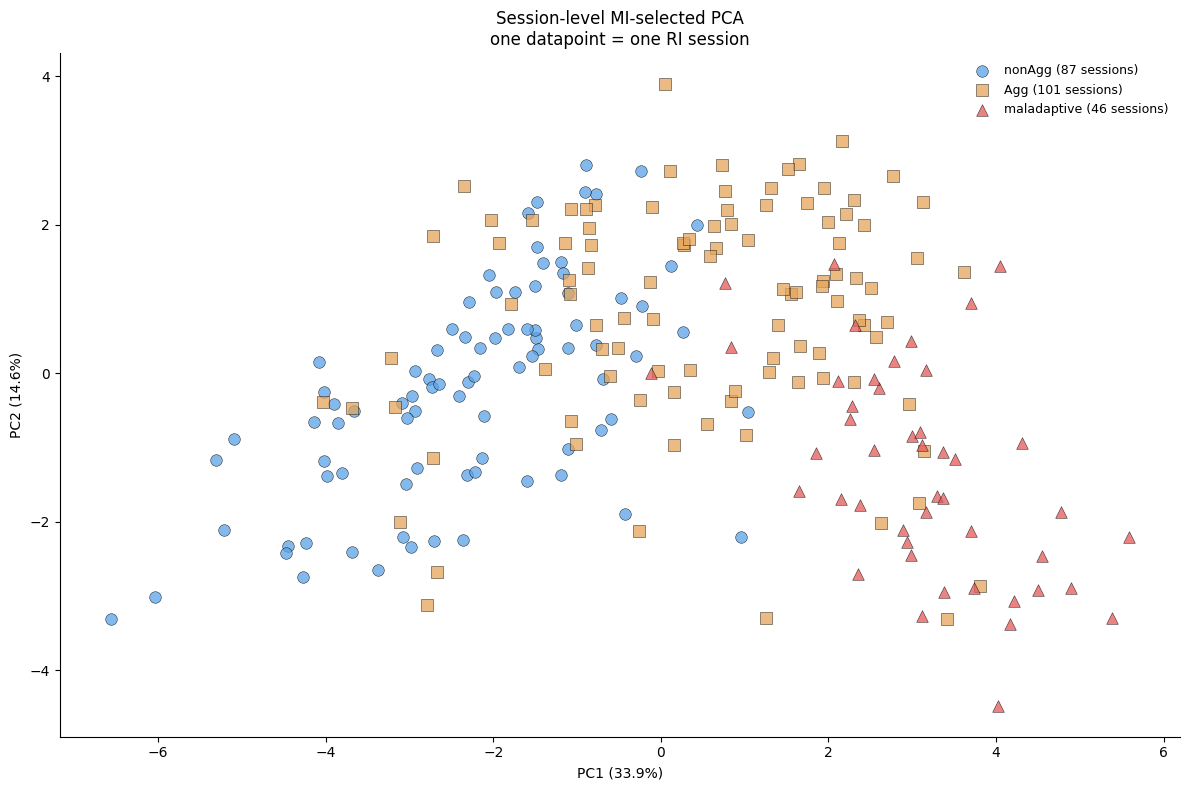

In [314]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive"
]

# -----------------------------
# one row = one mouse-day/session
# -----------------------------
session_df = df.copy()

# clean labels
session_df["group"] = session_df["group"].astype(str).str.strip()
session_df["day"] = pd.to_numeric(session_df["day"], errors="coerce")

# -----------------------------
# remove psilocybin post-treatment sessions
# -----------------------------
session_df = session_df[
    ~session_df["group"].isin([
        "maladaptive Psilocybin",
        "maladaptive after Psilocybin"
    ])
].copy()

# -----------------------------
# remove unintended maladaptive baseline day 0 sessions
# -----------------------------
session_df = session_df[
    ~(
        (session_df["group"] == "maladaptive baseline") &
        (session_df["day"] == 0)
    )
].copy()

# -----------------------------
# merge baseline + saline into one maladaptive group
# -----------------------------
session_df["group_plot"] = session_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})

# keep only groups of interest
session_df = session_df[
    session_df["group_plot"].isin(group_order)
].copy()

group_order_present = [
    g for g in group_order
    if g in session_df["group_plot"].unique()
]

print("Sessions included after merging baseline + saline:")
print(session_df["group_plot"].value_counts())

print("\nOriginal group labels included:")
print(session_df["group"].value_counts())

print("\nSessions per mouse/group:")
print(
    session_df
    .groupby(["mouse", "group", "group_plot"])
    .size()
    .reset_index(name="n_sessions")
    .sort_values(["group_plot", "mouse", "group"])
)

# -----------------------------
# features
# -----------------------------
X_df = session_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= 1].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(session_df["group_plot"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = min(19, len(valid_features))
top_features = mi_scores.head(top_n).index

print("\nTop MI syllables:")
print(mi_scores.head(top_n))

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=5)
Y = pca.fit_transform(X_selected_scaled)

session_df["PC1"] = Y[:, 0]
session_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")

# -----------------------------
# plot: one point per RI session
# -----------------------------
plt.figure(figsize=(12, 8))

for g in group_order_present:
    idx = session_df["group_plot"] == g

    plt.scatter(
        session_df.loc[idx, "PC1"],
        session_df.loc[idx, "PC2"],
        label=f"{g} ({idx.sum()} sessions)",
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.75,
        s=70,
        edgecolor="black",
        linewidth=0.4
    )

plt.legend(frameon=False, fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("Session-level MI-selected PCA\none datapoint = one RI session")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------
# output
# -----------------------------
session_pca_df = session_df.copy()

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive baseline",
    "maladaptive Saline",
    "maladaptive Psilocybin"
]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)

# -----------------------------
# prepare data
# -----------------------------
plot_df = mouse_df.copy()

# keep groups separate
plot_df["group_plot"] = plot_df["group"]

# keep only groups of interest
plot_df = plot_df[
    plot_df["group_plot"].isin(group_order)
].copy()

group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

print("Groups included:")
print(plot_df["group_plot"].value_counts())

# -----------------------------
# features
# -----------------------------
X_df = plot_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

min_recordings = 1
presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= min_recordings].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_plot"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(X_scaled, y, random_state=42)

mi_scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

top_n = max(2, int(len(valid_features) / 3))
top_features = mi_scores.head(top_n).index

print("\nTop MI features:")
print(mi_scores.head(top_n))

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")

# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]

# -----------------------------
# per-group syllable contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_plot"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order_present]

# same color range for loading barplot and heatmap
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])

Groups included:
group_plot
Agg                       11
nonAgg                     9
maladaptive baseline       7
maladaptive Psilocybin     4
maladaptive Saline         3
Name: count, dtype: int64

Top MI features:
syll_43    1.174780
syll_29    1.018017
syll_46    0.963127
syll_77    0.951341
syll_48    0.938324
syll_52    0.891447
syll_21    0.848400
syll_81    0.770678
syll_17    0.600181
syll_70    0.584054
syll_31    0.550810
syll_76    0.504410
syll_26    0.446776
syll_11    0.442290
syll_85    0.421897
syll_75    0.366726
syll_88    0.365643
syll_95    0.365307
syll_20    0.348644
dtype: float64

Explained variance:
PC1: 35.6%
PC2: 14.7%


In [324]:
# -----------------------------
# statistics: Saline vs Psilocybin on PC1 / PC2
# -----------------------------
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

# groups to compare
g1 = "maladaptive Saline"
g2 = "maladaptive Psilocybin"

# choose variables to test
pcs_to_test = ["PC1", "PC2"]

stats_rows = []

for pc in pcs_to_test:
    x = plot_df.loc[plot_df["group_plot"] == g1, pc].dropna().values
    y = plot_df.loc[plot_df["group_plot"] == g2, pc].dropna().values

    print(f"\n{pc}")
    print(f"{g1}: n = {len(x)}, mean = {np.mean(x):.3f}, SEM = {np.std(x, ddof=1) / np.sqrt(len(x)):.3f}")
    print(f"{g2}: n = {len(y)}, mean = {np.mean(y):.3f}, SEM = {np.std(y, ddof=1) / np.sqrt(len(y)):.3f}")

    # Welch's t-test
    t_stat, p_ttest = ttest_ind(
        x,
        y,
        equal_var=False,
        nan_policy="omit"
    )

    # Mann-Whitney U test
    u_stat, p_mwu = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    mean_diff = np.mean(y) - np.mean(x)

    stats_rows.append({
        "comparison": f"{g2} - {g1}",
        "PC": pc,
        "n_saline": len(x),
        "n_psilocybin": len(y),
        "mean_saline": np.mean(x),
        "mean_psilocybin": np.mean(y),
        "mean_difference_psilo_minus_saline": mean_diff,
        "welch_t": t_stat,
        "welch_p": p_ttest,
        "mannwhitney_U": u_stat,
        "mannwhitney_p": p_mwu
    })

stats_df = pd.DataFrame(stats_rows)

print("\nStatistical comparison:")
display(stats_df)


PC1
maladaptive Saline: n = 3, mean = 3.170, SEM = 0.411
maladaptive Psilocybin: n = 4, mean = 1.879, SEM = 0.565

PC2
maladaptive Saline: n = 3, mean = 0.449, SEM = 0.538
maladaptive Psilocybin: n = 4, mean = -2.391, SEM = 1.242

Statistical comparison:


,comparison,PC,n_saline,n_psilocybin,mean_saline,mean_psilocybin,mean_difference_psilo_minus_saline,welch_t,welch_p,mannwhitney_U,mannwhitney_p
0,maladaptive Psilocybin - maladaptive Saline,PC1,3,4,3.169941,1.878706,-1.291235,1.848006,0.124582,9.0,0.400000
1,maladaptive Psilocybin - maladaptive Saline,PC2,3,4,0.448581,-2.391359,-2.839939,2.097696,0.103570,11.0,0.114286


In [325]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}, dpi = 1000
)

# -----------------------------
# groups present in the current dataframe
# -----------------------------
group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]

heat_plot = heat[group_order_present]

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]

for g in group_order_present:
    idx = plot_df["group_plot"] == g

    ax.scatter(
        plot_df.loc[idx, "PC1"],
        plot_df.loc[idx, "PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")

# -----------------------------
# 2. Top PC1 syllable weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Syllable")
ax.set_title("Top syllable weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order_present):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order_present) + 1))
ax.set_xticklabels(group_order_present, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Syllable contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    heat_plot,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat_plot.columns)))
ax.set_xticklabels(heat_plot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heat_plot.index)))
ax.set_yticklabels(heat_plot.index)

ax.set_title("Syllable contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

In [158]:
print(plot_df["group"].value_counts())
print(plot_df["group_merged"].value_counts())

group
Agg                     11
nonAgg                   9
maladaptive baseline     7
maladaptive Saline       3
Name: count, dtype: int64
group_merged
Agg                   11
nonAgg                 9
maladaptive            7
maladaptive Saline     3
Name: count, dtype: int64


Sessions included:
group_plot
Agg                       101
nonAgg                     87
maladaptive baseline       35
maladaptive Psilocybin     13
maladaptive Saline         11
Name: count, dtype: int64

Original group labels:
group
Agg                       101
nonAgg                     87
maladaptive baseline       35
maladaptive Psilocybin     13
maladaptive Saline         11
Name: count, dtype: int64

Top MI syllables:
syll_21    0.475867
syll_81    0.371671
syll_52    0.335202
syll_31    0.324411
syll_33    0.293759
syll_85    0.284329
syll_95    0.234358
syll_68    0.191172
syll_27    0.184225
syll_97    0.179695
syll_28    0.164573
syll_11    0.156315
syll_36    0.155418
syll_15    0.152109
syll_87    0.139961
syll_39    0.139321
syll_67    0.133434
syll_47    0.132803
syll_34    0.131383
dtype: float64

Explained variance:
PC1: 31.6%
PC2: 19.3%


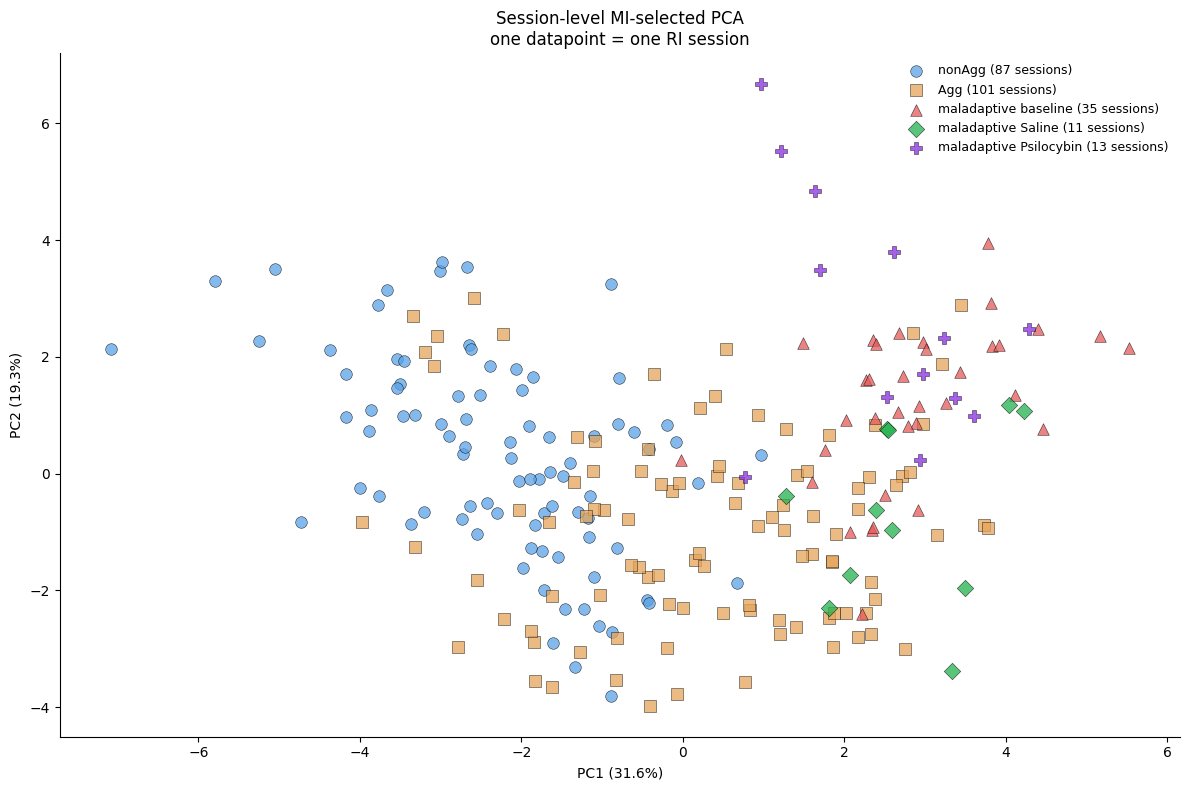

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive baseline",
    "maladaptive Saline",
    "maladaptive Psilocybin"
]

# -----------------------------
# one row = one mouse-day/session
# -----------------------------
session_df = df.copy()

# standardize labels if your df uses "after" names
session_df["group_plot"] = session_df["group"].replace({
    "maladaptive after Saline": "maladaptive Saline",
    "maladaptive after Psilocybin": "maladaptive Psilocybin"
})

# keep only groups of interest
session_df = session_df[
    session_df["group_plot"].isin(group_order)
].copy()

group_order_present = [
    g for g in group_order
    if g in session_df["group_plot"].unique()
]

print("Sessions included:")
print(session_df["group_plot"].value_counts())

print("\nOriginal group labels:")
print(df["group"].value_counts())

# -----------------------------
# features
# -----------------------------
X_df = session_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= 1].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(session_df["group_plot"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = min(19, len(valid_features))
top_features = mi_scores.head(top_n).index

print("\nTop MI syllables:")
print(mi_scores.head(top_n))

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=5)
Y = pca.fit_transform(X_selected_scaled)

session_df["PC1"] = Y[:, 0]
session_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")

# -----------------------------
# plot: one point per RI session
# -----------------------------
plt.figure(figsize=(12, 8))

for g in group_order_present:
    idx = session_df["group_plot"] == g

    plt.scatter(
        session_df.loc[idx, "PC1"],
        session_df.loc[idx, "PC2"],
        label=f"{g} ({idx.sum()} sessions)",
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.75,
        s=70,
        edgecolor="black",
        linewidth=0.4
    )

plt.legend(frameon=False, fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("Session-level MI-selected PCA\none datapoint = one RI session")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [64]:
inspect = df.copy()
inspect["group"] = inspect["group"].astype(str).str.strip()
inspect["day"] = pd.to_numeric(inspect["day"], errors="coerce")

print("Raw group labels and counts:")
print(inspect["group"].value_counts().to_string())
print("\nDay range:", np.nanmin(inspect["day"]), "to", np.nanmax(inspect["day"]))
print("\nSessions per (group x day) — pivot:")
print(pd.crosstab(inspect["group"], inspect["day"]).to_string())
print("\nDistinct mice per group:")
print(inspect.groupby("group")["mouse"].nunique().to_string())
dpm = inspect.groupby("mouse")["day"].nunique()
print(f"\nDays per mouse: min={dpm.min()}, median={dpm.median()}, max={dpm.max()}")

Raw group labels and counts:
group
Agg                       101
nonAgg                     87
maladaptive baseline       35
maladaptive Psilocybin     13
maladaptive Saline         11

Day range: 1 to 19

Sessions per (group x day) — pivot:
day                     1   2   3   4   5   6   7   8   9   10  11  12  16  17  18  19
group                                                                                 
Agg                      0  11  11  11  11  11   3   5   6   8   7   7   3   3   2   2
maladaptive Psilocybin   0   0   0   0   0   0   0   0   0   0   0   0   4   3   3   3
maladaptive Saline       0   0   0   0   0   0   0   0   0   0   0   0   2   3   3   3
maladaptive baseline     7   7   7   7   7   0   0   0   0   0   0   0   0   0   0   0
nonAgg                   0   9   8   9   9   9   1   7   8   7   8   8   1   1   1   1

Distinct mice per group:
group
Agg                       11
maladaptive Psilocybin     4
maladaptive Saline         3
maladaptive baseline       7
n

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

TREATMENT_DAY = 5.5

# ===================== rebuild raw with pheno/treatment/mal_score =====================
raw = df.copy()
raw["group"] = raw["group"].astype(str).str.strip()
raw["day"] = pd.to_numeric(raw["day"], errors="coerce")
raw = raw.dropna(subset=["day"]).copy()
raw["pheno"] = raw["group"].replace({
    "naive Agg": "Agg", "naive nonAgg": "nonAgg",
    "maladaptive baseline": "maladaptive", "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive",
    "maladaptive Psilocybin": "maladaptive", "maladaptive after Psilocybin": "maladaptive"})
def _arm(g):
    if "Psilocybin" in g: return "psilocybin"
    if "Saline" in g:     return "saline"
    if "baseline" in g:   return "baseline"
    return "none"
raw["treatment"] = raw["group"].apply(_arm)
raw = raw[raw["pheno"].isin(["nonAgg", "Agg", "maladaptive"])].copy()

feat_cols = plot_df.filter(regex="^syll_").columns
def _logfeat(frame, cols):
    return np.log(frame[cols].reindex(columns=cols, fill_value=0)
                  .replace([np.inf, -np.inf], np.nan).fillna(0).values + 1e-8)

# per-mouse reference fit, MI top 1/3, project all sessions
ref_mouse = (raw[raw["treatment"].isin(["none", "baseline"])]
             .groupby(["mouse", "pheno"], as_index=False).mean(numeric_only=True))
_y = LabelEncoder().fit_transform(ref_mouse["pheno"].values)
_mi = mutual_info_classif(StandardScaler().fit_transform(_logfeat(ref_mouse, feat_cols)),
                          _y, random_state=42)
_k = max(1, len(feat_cols) // 3)
top_cols = feat_cols[np.argsort(_mi)[::-1][:_k]]
_scaler = StandardScaler().fit(_logfeat(ref_mouse, top_cols))
_pca = PCA(n_components=5).fit(_scaler.transform(_logfeat(ref_mouse, top_cols)))
def _score(frame):
    return _pca.transform(_scaler.transform(_logfeat(frame, top_cols)))[:, 0]
ref_mouse["s"] = _score(ref_mouse)
_sign = -1.0 if (ref_mouse.loc[ref_mouse.pheno=="maladaptive","s"].median()
                 < ref_mouse.loc[ref_mouse.pheno=="nonAgg","s"].median()) else 1.0
raw["mal_score"] = _sign * _score(raw)

# ===================== the plot =====================
def make_cat(r):
    if r["pheno"] in ("nonAgg", "Agg"):
        return r["pheno"]
    return {"none": "maladaptive baseline",
            "baseline": "maladaptive baseline",
            "psilocybin": "maladaptive psilocybin",
            "saline": "maladaptive saline"}[r["treatment"]]
raw["cat"] = raw.apply(make_cat, axis=1)

cats = ["nonAgg", "Agg", "maladaptive baseline",
        "maladaptive psilocybin", "maladaptive saline"]
colors = {
    "nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive baseline": "#E65A5A",
    "maladaptive psilocybin": "#7B4FA3", "maladaptive saline": "#4A4A4A",
}
days = sorted(raw["day"].unique())
n = len(cats)
width = 0.16

fig, ax = plt.subplots(figsize=(18, 7))
for i, c in enumerate(cats):
    sub = raw[raw["cat"] == c]
    data, pos = [], []
    for d in days:
        v = sub.loc[sub["day"] == d, "mal_score"].values
        if len(v) > 0:
            data.append(v)
            pos.append(d + (i - (n - 1) / 2) * width)
    if data:
        bp = ax.boxplot(data, positions=pos, widths=width * 0.9, patch_artist=True,
                        showfliers=False, showmeans=True, manage_ticks=False,
                        meanprops=dict(marker="D", markerfacecolor="black",
                                       markeredgecolor="none", markersize=3))
        for box in bp["boxes"]:
            box.set(facecolor=colors[c], alpha=0.6, edgecolor="black", linewidth=0.4)
        for med in bp["medians"]:
            med.set(color="black", linewidth=1.1)

ax.axvline(TREATMENT_DAY, color="red", ls=":", lw=1.6)
ax.text(TREATMENT_DAY + 0.1, ax.get_ylim()[1], "treatment", color="red", fontsize=9, va="top")
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xticks(days)
ax.set_xlabel("experiment day")
ax.set_ylabel("PC1-axis score  (higher = more maladaptive)")
ax.set_title("Phenotype scores across the experiment — box per group per day "
             "(diamond = group mean)")
ax.legend(handles=[Patch(facecolor=colors[c], edgecolor="black", alpha=0.6, label=c)
                   for c in cats], title="group", fontsize=9, ncol=2, loc="best")
plt.tight_layout()
plt.show()

In [91]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

# ===================== rebuild raw with pheno/treatment/mal_score =====================
raw = df.copy()
raw["group"] = raw["group"].astype(str).str.strip()
raw["day"] = pd.to_numeric(raw["day"], errors="coerce")
raw = raw.dropna(subset=["day"]).copy()
raw["pheno"] = raw["group"].replace({
    "naive Agg": "Agg", "naive nonAgg": "nonAgg",
    "maladaptive baseline": "maladaptive", "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive",
    "maladaptive Psilocybin": "maladaptive", "maladaptive after Psilocybin": "maladaptive"})
def _arm(g):
    if "Psilocybin" in g: return "psilocybin"
    if "Saline" in g:     return "saline"
    if "baseline" in g:   return "baseline"
    return "none"
raw["treatment"] = raw["group"].apply(_arm)
raw = raw[raw["pheno"].isin(["nonAgg", "Agg", "maladaptive"])].copy()

feat_cols = plot_df.filter(regex="^syll_").columns
def _logfeat(frame, cols):
    return np.log(frame[cols].reindex(columns=cols, fill_value=0)
                  .replace([np.inf, -np.inf], np.nan).fillna(0).values + 1e-8)

ref_mouse = (raw[raw["treatment"].isin(["none", "baseline"])]
             .groupby(["mouse", "pheno"], as_index=False).mean(numeric_only=True))
_y = LabelEncoder().fit_transform(ref_mouse["pheno"].values)
_mi = mutual_info_classif(StandardScaler().fit_transform(_logfeat(ref_mouse, feat_cols)),
                          _y, random_state=42)
_k = max(1, len(feat_cols) // 3)
top_cols = feat_cols[np.argsort(_mi)[::-1][:_k]]
_scaler = StandardScaler().fit(_logfeat(ref_mouse, top_cols))
_pca = PCA(n_components=5).fit(_scaler.transform(_logfeat(ref_mouse, top_cols)))
def _score(frame):
    return _pca.transform(_scaler.transform(_logfeat(frame, top_cols)))[:, 0]
ref_mouse["s"] = _score(ref_mouse)
_sign = -1.0 if (ref_mouse.loc[ref_mouse.pheno=="maladaptive","s"].median()
                 < ref_mouse.loc[ref_mouse.pheno=="nonAgg","s"].median()) else 1.0
raw["mal_score"] = _sign * _score(raw)

# ===================== category =====================
def make_cat(r):
    if r["pheno"] in ("nonAgg", "Agg"):
        return r["pheno"]
    return {"none": "maladaptive baseline", "baseline": "maladaptive baseline",
            "psilocybin": "maladaptive psilocybin", "saline": "maladaptive saline"}[r["treatment"]]
raw["cat"] = raw.apply(make_cat, axis=1)

cats = ["nonAgg", "Agg", "maladaptive baseline",
        "maladaptive psilocybin", "maladaptive saline"]

# ===================== per-group OLS slope of mal_score over day =====================
print("Per-group slope of mal_score vs experiment day (session-level OLS):\n")
print(f"{'group':24s} {'slope/day':>10s} {'p':>9s} {'r':>7s} {'n_sess':>7s} {'days':>10s}")
for c in cats:
    sub = raw[raw["cat"] == c]
    x = sub["day"].values.astype(float)
    yv = sub["mal_score"].values.astype(float)
    if len(np.unique(x)) < 2:
        print(f"{c:24s} {'n/a':>10s} {'':>9s} {'':>7s} {len(yv):>7d}  (single day)")
        continue
    res = stats.linregress(x, yv)
    dmin, dmax = int(x.min()), int(x.max())
    print(f"{c:24s} {res.slope:>+10.4f} {res.pvalue:>9.4f} {res.rvalue:>+7.2f} "
          f"{len(yv):>7d} {f'{dmin}-{dmax}':>10s}")

print("\nslope = change in mal_score per experiment day (session-level, pooled).")
print("Note: pooled OLS ignores within-mouse structure; for the treated arms (few")
print("mice, few days) treat these as descriptive only.")

Per-group slope of mal_score vs experiment day (session-level OLS):

group                     slope/day         p       r  n_sess       days
nonAgg                      +0.1384    0.1894   +0.14      87       2-19
Agg                         -0.0327    0.7357   -0.03     101       2-19
maladaptive baseline        +0.1116    0.7675   +0.05      35        1-5
maladaptive psilocybin      +0.2248    0.7079   +0.12      13      16-19
maladaptive saline          +0.2271    0.8054   +0.08      11      16-19

slope = change in mal_score per experiment day (session-level, pooled).
Note: pooled OLS ignores within-mouse structure; for the treated arms (few
mice, few days) treat these as descriptive only.


================ AXIS VALIDITY (leak-free, per-mouse) ================
nonAgg vs Agg  CV ROC-AUC = 0.970   perm p=0.0050 (null mean 0.637)  [MI top 1/3, n_mice={'Agg': 11, 'nonAgg': 9}]
  -> axis is STRONG: the escalation result below is interpretable.

Median agg_score by group (in-sample axis, for the trajectory):
pheno
Agg       36.20
nonAgg   -55.27
Days present: 2-19, mice: {'Agg': 11, 'nonAgg': 9}

================ ESCALATION MODEL: agg_score ~ day * group ================
                         Coef. Std.Err.       z  P>|z|   [0.025   0.975]
Intercept              -46.787   11.107  -4.212  0.000  -68.557  -25.018
C(group)[T.Agg]         75.173   14.800   5.079  0.000   46.166  104.181
day_c                   -1.213    1.535  -0.790  0.429   -4.222    1.796
day_c:C(group)[T.Agg]    0.734    2.010   0.365  0.715   -3.205    4.672
Group Var              648.817    9.539                                 
Group x day_c Cov      -63.445    1.132                                 
day_c

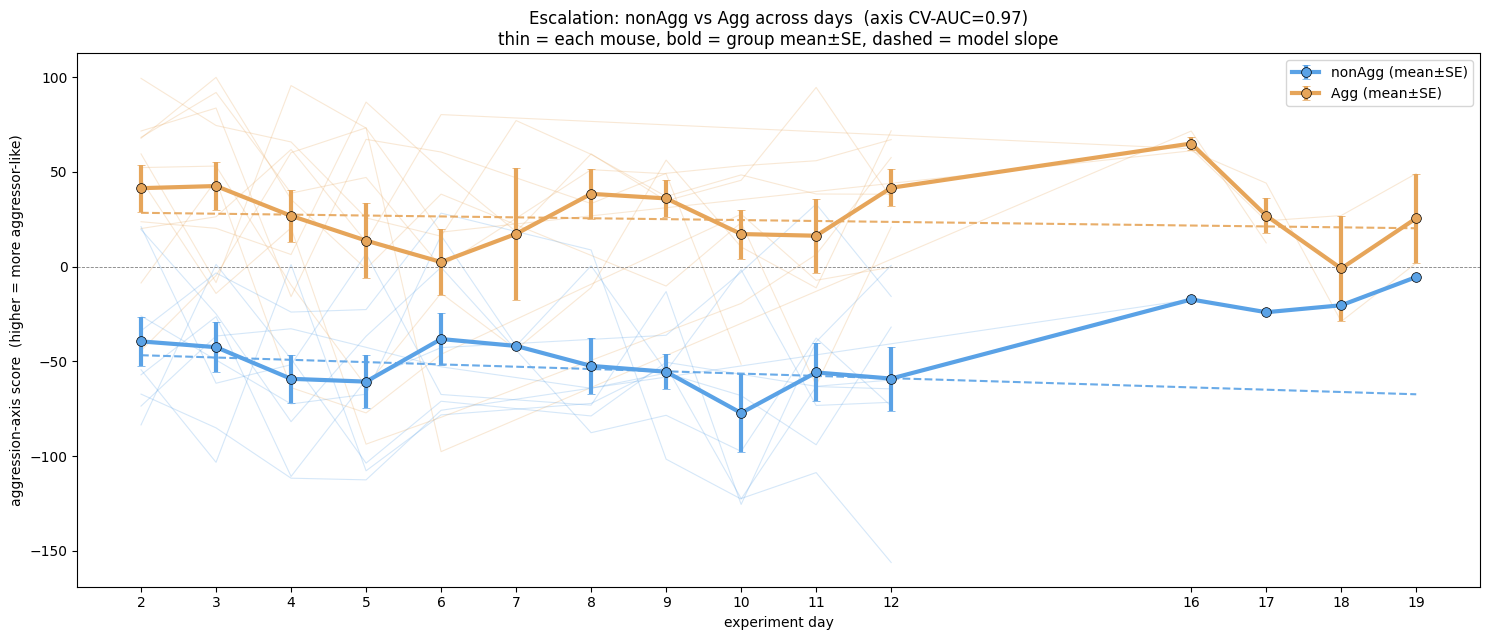

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

# =====================================================================
# Build session table, restrict to nonAgg + Agg
# =====================================================================
raw = df.copy()
raw["group"] = raw["group"].astype(str).str.strip()
raw["day"] = pd.to_numeric(raw["day"], errors="coerce")
raw = raw.dropna(subset=["day"]).copy()
raw["pheno"] = raw["group"].replace({"naive Agg": "Agg", "naive nonAgg": "nonAgg"})
raw = raw[raw["pheno"].isin(["nonAgg", "Agg"])].copy()

feat_cols = plot_df.filter(regex="^syll_").columns
def lf(frame, cols):
    return np.log(frame[cols].reindex(columns=cols, fill_value=0)
                  .replace([np.inf, -np.inf], np.nan).fillna(0).values + 1e-8)

K_FRAC = 3   # MI keeps top 1/K_FRAC of features (this cell used //5)

# =====================================================================
# (0) AXIS VALIDITY FIRST: leak-free per-mouse CV AUC for nonAgg vs Agg
#     Fit MI + scaler + LDA INSIDE each fold on per-mouse averages.
#     This tells you whether the aggression axis generalizes BEFORE
#     interpreting any escalation slope.
# =====================================================================
permouse = raw.groupby(["mouse", "pheno"], as_index=False).mean(numeric_only=True)
ylab = permouse["pheno"].values
yb = (ylab == "Agg").astype(int)
n_split = min(5, np.bincount(yb).min())
cv = StratifiedKFold(n_split, shuffle=True, random_state=SEED)

def cv_auc(yb_in):
    oof = np.full(len(yb_in), np.nan)
    for tr, te in cv.split(np.zeros(len(yb_in)), yb_in):
        ph_tr = np.array(["Agg" if v else "nonAgg" for v in yb_in[tr]])
        Xtr_all = lf(permouse.iloc[tr], feat_cols)
        # MI selection INSIDE the fold
        mi_in = mutual_info_classif(StandardScaler().fit_transform(Xtr_all),
                                    yb_in[tr], random_state=SEED)
        cols_in = feat_cols[np.argsort(mi_in)[::-1][:max(1, len(feat_cols)//K_FRAC)]]
        sc = StandardScaler().fit(lf(permouse.iloc[tr], cols_in))
        ld = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto").fit(
            sc.transform(lf(permouse.iloc[tr], cols_in)), ph_tr)
        d = ld.decision_function(sc.transform(lf(permouse.iloc[te], cols_in))).ravel()
        oof[te] = d
    auc = roc_auc_score(yb_in, oof)
    return max(auc, 1 - auc)

obs_auc = cv_auc(yb)
N_PERM = 200
null = np.array([cv_auc(rng.permutation(yb)) for _ in range(N_PERM)])
p_auc = (1 + np.sum(null >= obs_auc)) / (N_PERM + 1)

print("================ AXIS VALIDITY (leak-free, per-mouse) ================")
print(f"nonAgg vs Agg  CV ROC-AUC = {obs_auc:.3f}   "
      f"perm p={p_auc:.4f} (null mean {null.mean():.3f})  "
      f"[MI top 1/{K_FRAC}, n_mice={dict(zip(*np.unique(ylab, return_counts=True)))}]")
if obs_auc > 0.85:
    print("  -> axis is STRONG: the escalation result below is interpretable.")
elif p_auc < 0.05:
    print("  -> axis is REAL but modest: interpret escalation cautiously.")
else:
    print("  -> axis is WEAK/at chance: a null escalation result is NOT interpretable "
          "(the ruler itself doesn't reliably measure aggression).")

# =====================================================================
# AGGRESSION AXIS (full fit on all per-mouse data, for scoring sessions)
# =====================================================================
y_pm = LabelEncoder().fit_transform(permouse["pheno"].values)
mi = mutual_info_classif(StandardScaler().fit_transform(lf(permouse, feat_cols)),
                         y_pm, random_state=42)
top_cols = feat_cols[np.argsort(mi)[::-1][:max(1, len(feat_cols)//K_FRAC)]]
scaler = StandardScaler().fit(lf(permouse, top_cols))
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto").fit(
    scaler.transform(lf(permouse, top_cols)), permouse["pheno"].values)
def score(frame):
    return lda.decision_function(scaler.transform(lf(frame, top_cols))).ravel()
permouse["s"] = score(permouse)
sign = 1.0 if (permouse.loc[permouse.pheno == "Agg", "s"].median()
               > permouse.loc[permouse.pheno == "nonAgg", "s"].median()) else -1.0
raw["agg_score"] = sign * score(raw)

print("\nMedian agg_score by group (in-sample axis, for the trajectory):")
print(raw.groupby("pheno")["agg_score"].median().round(2).to_string())
print(f"Days present: {int(raw['day'].min())}-{int(raw['day'].max())}, "
      f"mice: {raw.groupby('pheno')['mouse'].nunique().to_dict()}")

# =====================================================================
# ESCALATION TEST: mixed model  agg_score ~ day * group  + (day | mouse)
# =====================================================================
md = raw.copy()
md["group"] = pd.Categorical(md["pheno"], categories=["nonAgg", "Agg"])
md["day_c"] = md["day"] - md["day"].min()

esc = smf.mixedlm("agg_score ~ day_c * C(group)", md, groups=md["mouse"], re_formula="~day_c")
fit = None
for m in ["lbfgs", "cg", "powell"]:
    try:
        fit = esc.fit(reml=False, method=m, maxiter=1000); break
    except Exception:
        continue

print("\n================ ESCALATION MODEL: agg_score ~ day * group ================")
if fit is not None:
    print(fit.summary().tables[1])
    b_day = fit.params.get("day_c", np.nan)
    b_int = fit.params.get("day_c:C(group)[T.Agg]", np.nan)
    p_int = fit.pvalues.get("day_c:C(group)[T.Agg]", np.nan)
    print(f"\nnonAgg slope (day_c)            = {b_day:+.4f} /day")
    print(f"Agg EXTRA slope (interaction)   = {b_int:+.4f} /day   p={p_int:.4f}")
    print(f"Agg total slope                 = {b_day + b_int:+.4f} /day")
    verdict = ("Agg escalates faster than nonAgg" if (b_int > 0 and p_int < 0.05)
               else "no significant differential escalation on this axis")
    print(f"  -> ESCALATION test = interaction p={p_int:.4f}: {verdict}")
    if obs_auc <= 0.85 and not (b_int > 0 and p_int < 0.05):
        print("  CAUTION: axis AUC is not strong, so this null is weak evidence "
              "of 'no escalation' (could be the axis, not the biology).")
else:
    print("Mixed model did not converge; try re_formula='1' (random intercept only).")

# =====================================================================
# FIGURE
# =====================================================================
gcol = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A"}
days = sorted(raw["day"].unique())
fig, ax = plt.subplots(figsize=(15, 6.5))
for mouse, g in raw.groupby("mouse"):
    g = g.sort_values("day")
    gd = g.groupby("day")["agg_score"].mean()
    ax.plot(gd.index, gd.values, "-", color=gcol[g["pheno"].iloc[0]],
            alpha=0.25, linewidth=0.8)
for ph in ["nonAgg", "Agg"]:
    sub = raw[raw.pheno == ph]
    gm = sub.groupby("day")["agg_score"].mean()
    se = sub.groupby("day")["agg_score"].sem()
    ax.errorbar(gm.index, gm.values, yerr=se.values, fmt="-o", color=gcol[ph],
                lw=3, markersize=7, capsize=3, markeredgecolor="black",
                markeredgewidth=0.5, label=f"{ph} (mean±SE)", zorder=5)
    if fit is not None:
        xx = np.array(days) - min(days)
        if ph == "nonAgg":
            yy = fit.params["Intercept"] + fit.params["day_c"] * xx
        else:
            yy = (fit.params["Intercept"] + fit.params.get("C(group)[T.Agg]", 0)
                  + (fit.params["day_c"] + fit.params.get("day_c:C(group)[T.Agg]", 0)) * xx)
        ax.plot(days, yy, "--", color=gcol[ph], lw=1.5, alpha=0.9)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xticks(days)
ax.set_xlabel("experiment day")
ax.set_ylabel("aggression-axis score  (higher = more aggressor-like)")
ax.set_title(f"Escalation: nonAgg vs Agg across days  (axis CV-AUC={obs_auc:.2f})\n"
             "thin = each mouse, bold = group mean±SE, dashed = model slope")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

Per-day psilocybin vs saline (maladaptive arms):

 day  n_psilo  n_saline  median_psilo  median_saline   p    |r|  q_FDR sig
  16        4         2        6.0196         2.9735 NaN    NaN    NaN    
  17        3         3        7.0874         4.7191 0.7 0.3333    0.7    
  18        3         3        7.4602         7.9182 0.7 0.3333    0.7    
  19        3         3        6.9141         4.5520 0.4 0.5556    0.7    

* = q<0.05 after FDR across days   (raw*) = uncorrected p<0.05 only
Negative (median_psilo < median_saline) = psilocybin lower on the maladaptive axis.

0 day(s) significant after FDR; 0 at uncorrected p<0.05.


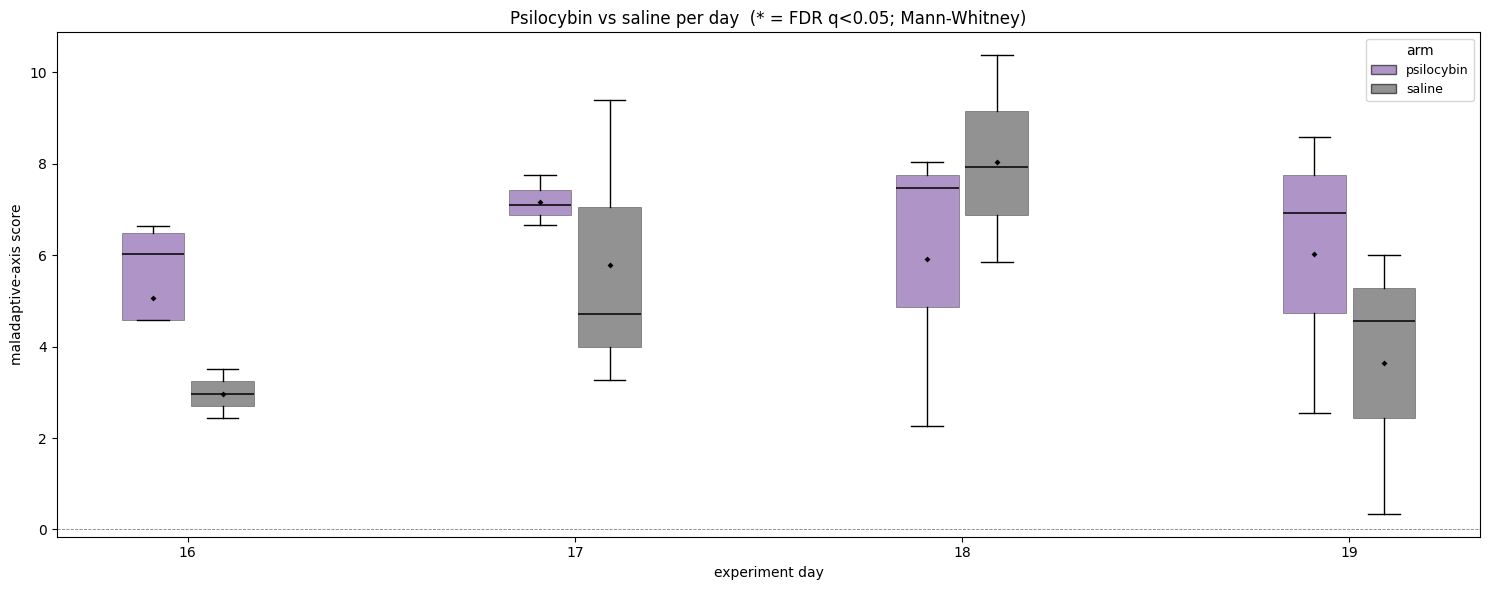

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

# expects `raw` with columns: pheno, treatment, day, mal_score, mouse (from model cell)
if "cat" not in raw.columns:
    def make_cat(r):
        if r["pheno"] in ("nonAgg", "Agg"):
            return r["pheno"]
        return {"none": "maladaptive baseline",
                "psilocybin": "maladaptive psilocybin",
                "saline": "maladaptive saline"}[r["treatment"]]
    raw = raw.copy()
    raw["cat"] = raw.apply(make_cat, axis=1)

# =====================================================================
# PER-DAY TEST: psilocybin vs saline (maladaptive arms only)
# Mann-Whitney U per day + Benjamini-Hochberg FDR across the tested days
# =====================================================================
mal = raw[raw["treatment"].isin(["psilocybin", "saline"])].copy()
days = sorted(mal["day"].unique())

rows = []
for d in days:
    p = mal.loc[(mal["day"] == d) & (mal["treatment"] == "psilocybin"), "mal_score"].values
    s = mal.loc[(mal["day"] == d) & (mal["treatment"] == "saline"), "mal_score"].values
    np_, ns = len(p), len(s)
    if np_ >= 3 and ns >= 3:                       # need a few per arm to test
        U, pval = mannwhitneyu(p, s, alternative="two-sided")
        r = abs(1 - 2 * U / (np_ * ns))            # rank-biserial effect size
        rows.append({"day": d, "n_psilo": np_, "n_saline": ns,
                     "median_psilo": np.median(p), "median_saline": np.median(s),
                     "p": pval, "|r|": r})
    else:
        rows.append({"day": d, "n_psilo": np_, "n_saline": ns,
                     "median_psilo": np.median(p) if np_ else np.nan,
                     "median_saline": np.median(s) if ns else np.nan,
                     "p": np.nan, "|r|": np.nan})

res = pd.DataFrame(rows)

# BH-FDR across days that were actually tested
tested = res["p"].notna()
pv = res.loc[tested, "p"].values
m = len(pv)
if m > 0:
    order = np.argsort(pv)
    bh = np.minimum.accumulate((pv[order] * m / np.arange(1, m + 1))[::-1])[::-1]
    q = np.empty(m); q[order] = np.clip(bh, 0, 1)
    res.loc[tested, "q_FDR"] = q
else:
    res["q_FDR"] = np.nan

res["sig"] = np.where(res["q_FDR"] < 0.05, "*",
              np.where(res["p"] < 0.05, "(raw*)", ""))

pd.set_option("display.width", 160)
print("Per-day psilocybin vs saline (maladaptive arms):\n")
print(res.round(4).to_string(index=False))
print("\n* = q<0.05 after FDR across days   (raw*) = uncorrected p<0.05 only")
print("Negative (median_psilo < median_saline) = psilocybin lower on the maladaptive axis.")
n_sig = int((res["q_FDR"] < 0.05).sum())
print(f"\n{n_sig} day(s) significant after FDR; "
      f"{int((res['p'] < 0.05).sum())} at uncorrected p<0.05.")

# =====================================================================
# FIGURE: psilocybin vs saline boxes per day, with significance marks
# =====================================================================
col = {"psilocybin": "#7B4FA3", "saline": "#4A4A4A"}
width = 0.18
fig, ax = plt.subplots(figsize=(15, 6))

for i, a in enumerate(["psilocybin", "saline"]):
    sub = mal[mal["treatment"] == a]
    data, pos = [], []
    for d in days:
        v = sub.loc[sub["day"] == d, "mal_score"].values
        if len(v) > 0:
            data.append(v); pos.append(d + (i - 0.5) * width)
    if data:
        bp = ax.boxplot(data, positions=pos, widths=width * 0.9, patch_artist=True,
                        showfliers=False, showmeans=True, manage_ticks=False,
                        meanprops=dict(marker="D", markerfacecolor="black",
                                       markeredgecolor="none", markersize=3))
        for box in bp["boxes"]:
            box.set(facecolor=col[a], alpha=0.6, edgecolor="black", linewidth=0.4)
        for med in bp["medians"]:
            med.set(color="black", linewidth=1.1)

# significance stars above each tested day
ymax = mal["mal_score"].max()
for _, r in res.iterrows():
    if r["sig"]:
        ax.text(r["day"], ymax * 1.05, r["sig"], ha="center", va="bottom",
                fontsize=13, color="red" if "*" in r["sig"] and "raw" not in r["sig"] else "grey")

ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xticks(days); ax.set_xlabel("experiment day")
ax.set_ylabel("maladaptive-axis score")
ax.set_title("Psilocybin vs saline per day  (* = FDR q<0.05; Mann-Whitney)")
ax.legend(handles=[Patch(facecolor=col[a], edgecolor="black", alpha=0.6, label=a)
                   for a in ["psilocybin", "saline"]], title="arm", fontsize=9)
plt.tight_layout(); plt.show()

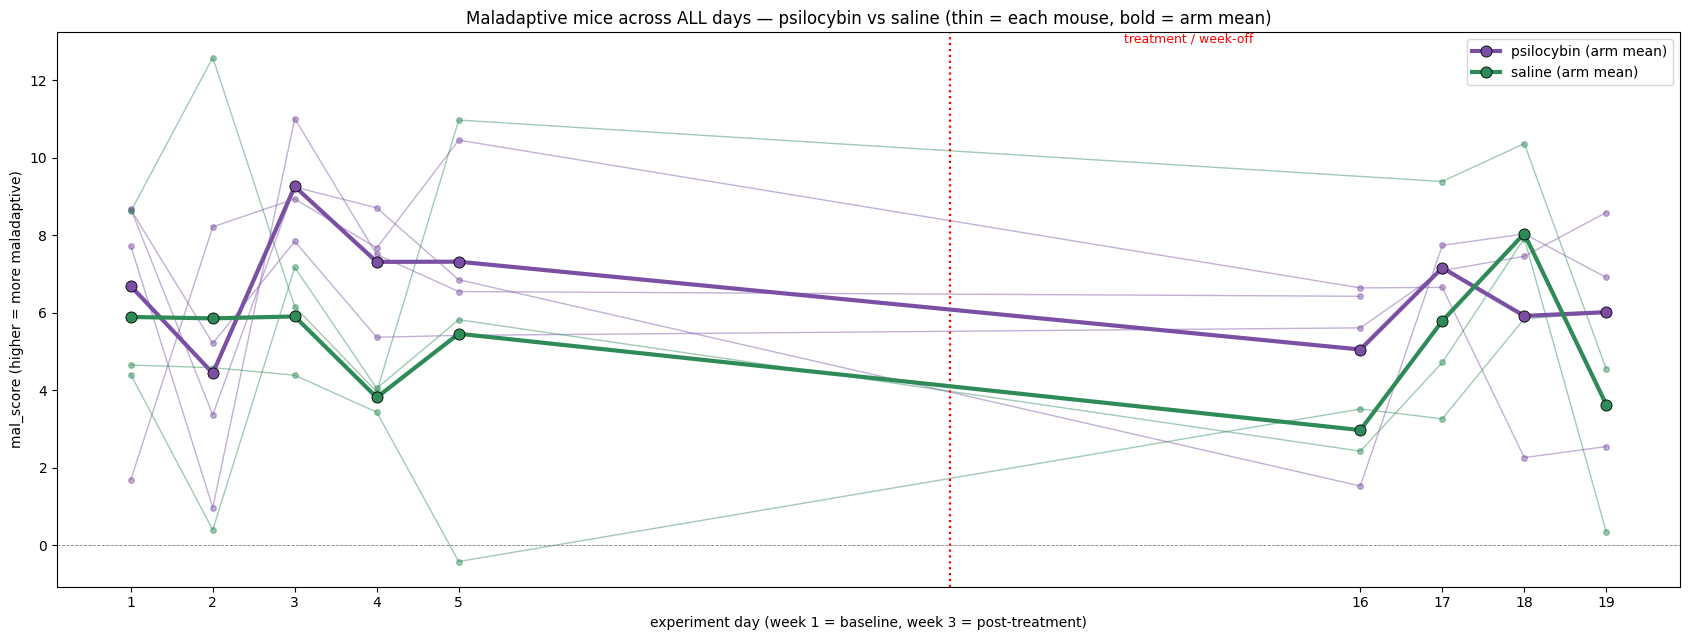

 day  n_p  n_s  psilo_mean  saline_mean   gap
   1    4    3        6.69         5.89  0.80
   2    4    3        4.44         5.86 -1.42
   3    4    3        9.26         5.91  3.35
   4    4    3        7.32         3.82  3.50
   5    4    3        7.32         5.46  1.86
  16    4    2        5.05         2.97  2.08
  17    3    3        7.16         5.79  1.37
  18    3    3        5.92         8.05 -2.13
  19    3    3        6.02         3.63  2.38

gap = psilo_mean - saline_mean  (negative = psilo less maladaptive that day)
Pre-treatment days should show gap ~0 (arms identical at baseline); a gap opening only AFTER treatment is the effect. Per-day N is tiny -> descriptive.


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# uses `raw` (per-session mal_score, day, pheno, treatment, mouse) from the model cell.
POST_START = 15
mal = raw[raw["pheno"] == "maladaptive"].copy()

# assign each maladaptive mouse its eventual arm (from week-3 sessions)
post = mal[(mal["day"] >= POST_START) & (mal["treatment"].isin(["psilocybin", "saline"]))]
arm_by_mouse = (post.groupby("mouse")["treatment"]
                .agg(lambda s: s.mode().iloc[0]).to_dict())
mal["arm"] = mal["mouse"].map(arm_by_mouse)
mal = mal.dropna(subset=["arm"])
mal = mal[mal["arm"].isin(["psilocybin", "saline"])].copy()

days = sorted(mal["day"].unique())
arm_col = {"psilocybin": "#7B4FA3", "saline": "#2E8B57"}

fig, ax = plt.subplots(figsize=(17, 6.5))

# thin per-mouse trajectories across ALL days
for mouse, g in mal.groupby("mouse"):
    g = g.sort_values("day")
    gd = g.groupby("day")["mal_score"].mean()
    ax.plot(gd.index, gd.values, "-o", color=arm_col[g["arm"].iloc[0]],
            alpha=0.45, markersize=4, linewidth=1.0)

# bold arm-mean trajectory per day
for a in ["psilocybin", "saline"]:
    sub = mal[mal["arm"] == a]
    md = sub.groupby("day")["mal_score"].mean()
    ax.plot(md.index, md.values, "-o", color=arm_col[a], linewidth=3,
            markersize=8, markeredgecolor="black", markeredgewidth=0.6,
            label=f"{a} (arm mean)", zorder=5)

ax.axvline((7 + POST_START) / 2 if POST_START > 8 else 7.5, color="red", ls=":", lw=1.6)
ax.text(POST_START - 0.3, ax.get_ylim()[1], "treatment / week-off",
        color="red", fontsize=9, va="top", ha="right")
ax.axhline(0, color="grey", lw=0.6, ls="--")

ax.set_xticks(days)
ax.set_xlabel("experiment day (week 1 = baseline, week 3 = post-treatment)")
ax.set_ylabel("mal_score (higher = more maladaptive)")
ax.set_title("Maladaptive mice across ALL days — psilocybin vs saline "
             "(thin = each mouse, bold = arm mean)")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

rows = []
for d in days:
    p = mal.loc[(mal.day == d) & (mal.arm == "psilocybin"), "mal_score"]
    s = mal.loc[(mal.day == d) & (mal.arm == "saline"), "mal_score"]
    rows.append({"day": d, "n_p": len(p), "n_s": len(s),
                 "psilo_mean": p.mean() if len(p) else np.nan,
                 "saline_mean": s.mean() if len(s) else np.nan,
                 "gap": (p.mean() - s.mean()) if (len(p) and len(s)) else np.nan})
print(pd.DataFrame(rows).round(2).to_string(index=False))
print("\ngap = psilo_mean - saline_mean  (negative = psilo less maladaptive that day)")
print("Pre-treatment days should show gap ~0 (arms identical at baseline); a gap "
      "opening only AFTER treatment is the effect. Per-day N is tiny -> descriptive.")

In [36]:
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu

POST_START = 15   # first day of week 3 — adjust to your coding
post = raw[(raw["treatment"].isin(["psilocybin", "saline"])) & (raw["day"] >= POST_START)]

# one value per mouse (mean of its week-3 sessions) — respects independence
per_mouse = post.groupby(["mouse", "treatment"])["mal_score"].mean().reset_index()
p = per_mouse.loc[per_mouse["treatment"] == "psilocybin", "mal_score"].values
s = per_mouse.loc[per_mouse["treatment"] == "saline", "mal_score"].values

print(f"psilocybin mice: n={len(p)}, median={np.median(p):.2f}")
print(f"saline mice    : n={len(s)}, median={np.median(s):.2f}")
if len(p) >= 3 and len(s) >= 3:
    U, pval = mannwhitneyu(p, s, alternative="two-sided")
    r = abs(1 - 2 * U / (len(p) * len(s)))
    print(f"Mann-Whitney p={pval:.4f}, |r|={r:.2f}")
    print(f"direction: psilocybin {'<' if np.median(p) < np.median(s) else '>='} saline")
else:
    print("Too few mice per arm even pooled — report descriptively (medians + per-mouse points).")

psilocybin mice: n=4, median=82.85
saline mice    : n=3, median=88.82
Mann-Whitney p=0.6286, |r|=0.33
direction: psilocybin < saline


MI-selected 49 of 99 syllables (reference groups only).
PC1 var=20.6%

Median refPC1 by group (axis never saw treated animals):
pheno
Agg            1.21
maladaptive    2.46
nonAgg        -2.07

=== Week-3 psilocybin vs saline on reference-only PC1 (MI top 49) ===
  psilocybin: n=4  median=1.09
  saline    : n=3  median=3.30
  Mann-Whitney p=0.1143  |r|=0.83  ->  psilo BELOW saline (amelioration)


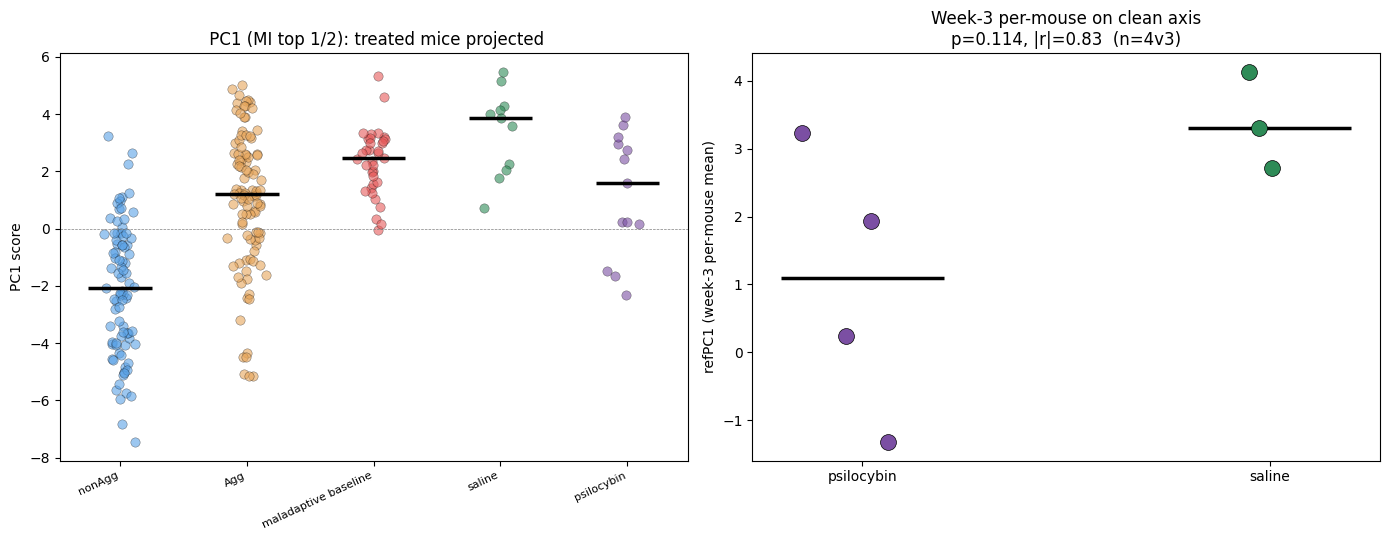


MI selection AND PCA both fit on reference groups only -> treated arms are projected, not fitted (no circularity, matches the 1/3-MI methodology).


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

POST_START = 15   # first day of week 3 — adjust to your day coding

# =====================================================================
# Build the session-level table with phenotype + treatment arm
# =====================================================================
raw = df.copy()
raw["group"] = raw["group"].astype(str).str.strip()
raw["day"] = pd.to_numeric(raw["day"], errors="coerce")
raw = raw.dropna(subset=["day"]).copy()
raw["pheno"] = raw["group"].replace({
    "naive Agg": "Agg", "naive nonAgg": "nonAgg",
    "maladaptive baseline": "maladaptive", "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive",
    "maladaptive Psilocybin": "maladaptive", "maladaptive after Psilocybin": "maladaptive"})
def arm(g):
    if "Psilocybin" in g: return "psilocybin"
    if "Saline" in g:     return "saline"
    if "baseline" in g:   return "baseline"
    return "none"
raw["treatment"] = raw["group"].apply(arm)
raw = raw[raw["pheno"].isin(["nonAgg", "Agg", "maladaptive"])].copy()

feat_cols = plot_df.filter(regex="^syll_").columns

# =====================================================================
# REFERENCE rows = nonAgg + Agg + maladaptive-baseline (NO treated animals)
# =====================================================================
is_ref = raw["treatment"].isin(["none", "baseline"])
ref = raw[is_ref]

def logfeat(frame, cols):
    return np.log(frame[cols].reindex(columns=cols, fill_value=0)
                  .replace([np.inf, -np.inf], np.nan).fillna(0).values + 1e-8)

# ---- MI feature selection: top 1/3, fit on REFERENCE groups only ----
Xref_all = logfeat(ref, feat_cols)
y_ref = LabelEncoder().fit_transform(ref["pheno"].values)
mi = mutual_info_classif(StandardScaler().fit_transform(Xref_all), y_ref, random_state=42)
k = max(1, len(feat_cols) // 2)
top_cols = feat_cols[np.argsort(mi)[::-1][:k]]
print(f"MI-selected {k} of {len(feat_cols)} syllables (reference groups only).")

# ---- PCA on the SELECTED features, reference rows only ----
Xref = logfeat(ref, top_cols)
scaler = StandardScaler().fit(Xref)
pca = PCA(n_components=5).fit(scaler.transform(Xref))

def pc1(frame):
    return pca.transform(scaler.transform(logfeat(frame, top_cols)))[:, 0]

# orient PC1 so maladaptive-baseline > nonAgg
ref_pc1 = pc1(ref)
ref_pheno = ref["pheno"].values
sign = -1.0 if np.median(ref_pc1[ref_pheno == "maladaptive"]) < \
               np.median(ref_pc1[ref_pheno == "nonAgg"]) else 1.0

raw["refPC1"] = sign * pc1(raw)
print(f"PC1 var={pca.explained_variance_ratio_[0]*100:.1f}%")
print("\nMedian refPC1 by group (axis never saw treated animals):")
print(raw.groupby("pheno")["refPC1"].median().round(2).to_string())

# =====================================================================
# TREATMENT TEST on the clean axis: per-mouse week-3 mean
# =====================================================================
post = raw[(raw["treatment"].isin(["psilocybin", "saline"])) & (raw["day"] >= POST_START)]
pm = post.groupby(["mouse", "treatment"])["refPC1"].mean().reset_index()
p = pm.loc[pm["treatment"] == "psilocybin", "refPC1"].values
s = pm.loc[pm["treatment"] == "saline", "refPC1"].values

print(f"\n=== Week-3 psilocybin vs saline on reference-only PC1 (MI top {k}) ===")
print(f"  psilocybin: n={len(p)}  median={np.median(p):.2f}")
print(f"  saline    : n={len(s)}  median={np.median(s):.2f}")
if len(p) >= 3 and len(s) >= 3:
    U, pv = mannwhitneyu(p, s, alternative="two-sided")
    r = abs(1 - 2 * U / (len(p) * len(s)))
    direction = "psilo BELOW saline (amelioration)" if np.median(p) < np.median(s) else "psilo >= saline"
    print(f"  Mann-Whitney p={pv:.4f}  |r|={r:.2f}  ->  {direction}")
else:
    pv = r = np.nan
    print("  too few per arm to test; report descriptively")

# =====================================================================
# FIGURE
# =====================================================================
gcol = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive baseline": "#E65A5A",
        "psilocybin": "#7B4FA3", "saline": "#2E8B57"}
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

cats = [("nonAgg", raw[(raw.pheno=="nonAgg")]["refPC1"]),
        ("Agg", raw[(raw.pheno=="Agg")]["refPC1"]),
        ("maladaptive baseline", raw[(raw.treatment=="baseline")]["refPC1"]),
        ("saline", raw[(raw.treatment=="saline") & (raw.day>=POST_START)]["refPC1"]),
        ("psilocybin", raw[(raw.treatment=="psilocybin") & (raw.day>=POST_START)]["refPC1"])]
for i, (name, vals) in enumerate(cats):
    vals = vals.values
    ax[0].scatter(np.random.normal(i, 0.06, len(vals)), vals, s=45, alpha=0.6,
                  color=gcol.get(name, "#888"), edgecolor="black", linewidth=0.3)
    if len(vals):
        ax[0].hlines(np.median(vals), i-0.25, i+0.25, color="black", lw=2.5, zorder=5)
ax[0].set_xticks(range(len(cats)))
ax[0].set_xticklabels([c[0] for c in cats], rotation=25, ha="right", fontsize=8)
ax[0].set_ylabel("PC1 score")
ax[0].set_title(" PC1 (MI top 1/2): treated mice projected")
ax[0].axhline(0, color="grey", lw=0.5, ls="--")

for xi, (vals, a) in enumerate([(p, "psilocybin"), (s, "saline")]):
    ax[1].scatter(np.random.normal(xi, 0.05, len(vals)), vals, s=130,
                  color=gcol[a], edgecolor="black", linewidth=0.5, zorder=3)
    if len(vals):
        ax[1].hlines(np.median(vals), xi-0.2, xi+0.2, color="black", lw=2.5)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["psilocybin", "saline"])
ax[1].set_ylabel("refPC1 (week-3 per-mouse mean)")
ptxt = f"p={pv:.3f}, |r|={r:.2f}" if len(p) >= 3 and len(s) >= 3 else "underpowered"
ax[1].set_title(f"Week-3 per-mouse on clean axis\n{ptxt}  (n={len(p)}v{len(s)})")
plt.tight_layout(); plt.show()

print("\nMI selection AND PCA both fit on reference groups only -> treated arms "
      "are projected, not fitted (no circularity, matches the 1/3-MI methodology).")